In [1]:
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import xarray as xr
import rioxarray as rxa
sns.set_theme()

from shapely import box, Polygon
import geopandas as gpd
import pandas as pd
import rasterio
import math
from datetime import datetime

from pathlib import Path

# ====== import my own functions =========
import sys
import os
project_root = str(Path(os.getcwd()).parent)

if project_root not in sys.path:
    sys.path.append(project_root)

%load_ext autoreload
%autoreload 2
# from scripts.layers import assemble_data, get_uavsar_coherence, get_uavsar_incidence, get_nlcd_layers
from scripts.layers import *
from scripts.validation import validate_date_pairs, make_reference_grid

/bsuhome/julialober/miniforge3/envs/coherence_v2/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
data_dir = '/bsuhome/julialober/scratch/coherence_data/'
file_info = pd.read_parquet(data_dir + 'coherence_files_overview.parquet')
file_info

,filename,file_type,flight_path,flight_num,date_reference,date_secondary,polarization,segment,absolute_path
0,uticam_21003_21004_002_210120_L090VV_01_BC.ann,ann_slc,uticam,21003,210120,NaN,NaN,NaN,/bsuhome/julialober/scratch/coherence_data/uav...
1,uticam_21003_21002_003_210115_L090VH_01_BC.ann,ann_slc,uticam,21003,210115,NaN,NaN,NaN,/bsuhome/julialober/scratch/coherence_data/uav...
2,uticam_21003_21013_003_210223_L090VH_01_BC.ann,ann_slc,uticam,21003,210223,NaN,NaN,NaN,/bsuhome/julialober/scratch/coherence_data/uav...
3,uticam_21003_21013_003_210223_L090VV_01_BC_s2_...,raw_slc,uticam,21003,210223,NaN,NaN,s2,/bsuhome/julialober/scratch/coherence_data/uav...
4,uticam_21003_21013_003_210223_L090VV_01_BC_s1_...,raw_slc,uticam,21003,210223,NaN,NaN,s1,/bsuhome/julialober/scratch/coherence_data/uav...
...,...,...,...,...,...,...,...,...,...
3789,lowman_23205_210115_210210_VV_s2_w5_int_coh.tif,int_pair,lowman,23205,210115,210210,VV,s2,/bsuhome/julialober/scratch/coherence_data/uav...
3790,lowman_23205_210120_HV-VH_s1_w5_crosspol_coh.tif,crosspol,lowman,23205,210120,NaN,HV-VH,s1,/bsuhome/julialober/scratch/coherence_data/uav...
3791,lowman_23205_210115_210127_VV_s2_w5_int_coh.tif,int_pair,lowman,23205,210115,210127,VV,s2,/bsuhome/julialober/scratch/coherence_data/uav...
3792,lowman_23205_200221_210127_HH_s1_w13_int_coh.tif,int_pair,lowman,23205,200221,210127,HH,s1,/bsuhome/julialober/scratch/coherence_data/uav...


In [3]:
meta = file_info[file_info['flight_path'] == 'rockmt']
meta = meta[meta['flight_num'] == '32109'] # this is the only path useful for my chosen site
summary_df = meta.pivot_table(index=['flight_path', 'flight_num'], 
                                columns='file_type', 
                                aggfunc='size', 
                                fill_value=0)
display(summary_df.join(meta.groupby(['flight_path', 'flight_num'])[['polarization', 'segment']].nunique().add_prefix('unique_')))

,,ann_slc,crosspol,geo_slc,int_pair,lkv,llh,raw_slc,unique_polarization,unique_segment
flight_path,flight_num,,,,,,,,,
rockmt,32109,32,8,32,28,1,1,32,2,1


## Assemble for RMNP

In [4]:
POL = 'VV'
int_pairs = meta[meta['file_type'] == 'int_pair']
int_pairs = int_pairs[int_pairs['polarization'] == POL]
print(f'Using only {POL} polarization.')

# establish an output directory 
fp_dest = data_dir + 'stacks/rockmt'
print(f'Output Zarr directory: {fp_dest}')

# get flight ids 
flight_ids = meta['flight_num'].unique()
print(f'Flight numbers: {flight_ids}')

# get all date pairs 
date_pairs_int = list(zip(int_pairs['date_reference'], int_pairs['date_secondary']))
dates = [(f"20{date[0]}", f"20{date[1]}") for date in date_pairs_int]
print(f'Number of date pairs: {len(dates)}')

# get bounding box 
filenames = [int_pairs[int_pairs['flight_num'] == f]['absolute_path'].iloc[0] for f in flight_ids]
all_bounds = [rasterio.open(f).bounds for f in filenames]
aoi = box(
    min(b[0] for b in all_bounds), # min left
    min(b[1] for b in all_bounds), # min bottom
    max(b[2] for b in all_bounds), # max right
    max(b[3] for b in all_bounds)  # max top
)

# small box for RMNP 
coords = [
    (-105.8462033234742, 40.45931483103253),
    (-105.7838780833698, 40.40425021552515),
    (-105.7136429921721, 40.44535712159221),
    (-105.7725118718758, 40.50104010750601),
    (-105.8462033234742, 40.45931483103253)
]

# Create the 2D Polygon
aoi = Polygon(coords)

print(f'AOI bounding box: {aoi}')

Using only VV polarization.
Output Zarr directory: /bsuhome/julialober/scratch/coherence_data/stacks/rockmt
Flight numbers: <ArrowStringArray>
['32109']
Length: 1, dtype: str
Number of date pairs: 28
AOI bounding box: POLYGON ((-105.8462033234742 40.45931483103253, -105.7838780833698 40.40425021552515, -105.7136429921721 40.44535712159221, -105.7725118718758 40.50104010750601, -105.8462033234742 40.45931483103253))


In [5]:
METRES_PER_DEGREE_AT_45_LAT: float = 111320.0 * math.cos(math.radians(45.0))
res = 30 
res_grid = res / METRES_PER_DEGREE_AT_45_LAT
ref_grid = make_reference_grid(aoi=aoi, crs='EPSG:4326', resolution=res_grid)

In [6]:
import logging

logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s',
    force=True 
)

In [9]:
cohs = get_uavsar_coherence(
    tile_aoi=aoi,
    date_pairs=validate_date_pairs(dates),
    flight_ids=flight_ids,
    crs='EPSG:4326',
    tile_ref_grid=ref_grid,
    fp=data_dir + 'uavsar_cohs/rockmt/',
)
cohs

<xarray.Dataset> Size: 10MB
Dimensions:      (flight_id: 1, pair: 28, y: 254, x: 348)
Coordinates:
  * flight_id    (flight_id) StringDType(na_object=nan) 16B '32109'
  * pair         (pair) <U13 1kB '200312_210310' ... '200212_200219'
  * y            (y) float64 2kB 40.5 40.5 40.5 40.5 ... 40.41 40.41 40.4 40.4
  * x            (x) float64 3kB -105.8 -105.8 -105.8 ... -105.7 -105.7 -105.7
    spatial_ref  int64 8B 0
Data variables:
    coherence    (flight_id, pair, y, x) float32 10MB 0.3224 0.3664 ... 0.4094

In [10]:
inc = get_uavsar_incidence(
    tile_aoi=aoi,
    flight_ids=flight_ids,
    fp_inc=data_dir + 'inc_angle/',
    tile_ref_grid=ref_grid,
    crs='EPSG:4326',
)
inc

<xarray.DataArray 'incidence_angle' (flight_id: 1, y: 254, x: 348)> Size: 707kB
array([[[75.55060199, 71.33097697, 74.04300901, ...,         nan,
                 nan,         nan],
        [78.31687464, 78.99824769, 75.76166968, ...,         nan,
                 nan,         nan],
        [82.020322  , 81.87396218, 81.43875075, ...,         nan,
                 nan,         nan],
        ...,
        [55.67289902, 57.32029575, 59.12641803, ..., 57.3667595 ,
         59.26340163, 58.40620356],
        [56.3026112 , 59.60349817, 61.3313891 , ..., 56.07476189,
         57.98997517, 57.88016485],
        [58.46658831, 61.17409202, 65.37072563, ..., 56.27341944,
         57.42377831, 59.50605362]]], shape=(1, 254, 348))
Coordinates:
  * flight_id    (flight_id) StringDType(na_object=nan) 16B '32109'
  * y            (y) float64 2kB 40.5 40.5 40.5 40.5 ... 40.41 40.41 40.4 40.4
  * x            (x) float64 3kB -105.8 -105.8 -105.8 ... -105.7 -105.7 -105.7
    spatial_ref  int64 8B 0

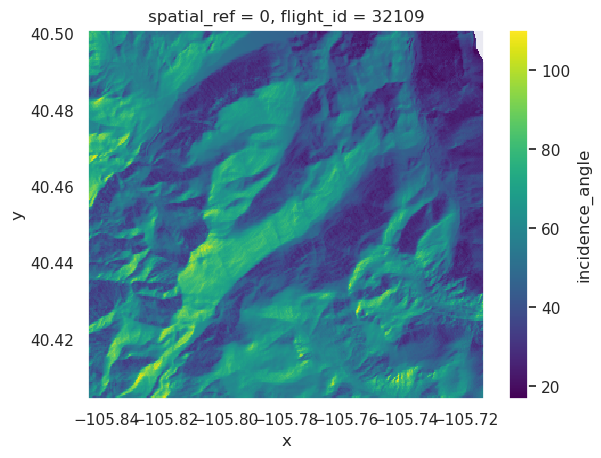

In [11]:
inc.plot()

In [12]:
nlcd = get_nlcd_layers(
    tile_aoi=aoi,
    crs='EPSG:4326',
    years={'cover': [2021], 'canopy': [2021]},
    tile_ref_grid=ref_grid,
)
nlcd

/bsuhome/julialober/miniforge3/envs/coherence_v2/lib/python3.11/site-packages/pygeoutils/pygeoutils.py:300: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  ds = xr.merge(


<xarray.Dataset> Size: 447kB
Dimensions:      (x: 348, y: 254)
Coordinates:
  * x            (x) float64 3kB -105.8 -105.8 -105.8 ... -105.7 -105.7 -105.7
  * y            (y) float64 2kB 40.5 40.5 40.5 40.5 ... 40.41 40.41 40.4 40.4
    spatial_ref  int64 8B 0
Data variables:
    cover_2021   (y, x) uint8 88kB 127 127 127 127 127 ... 127 127 127 127 127
    canopy_2021  (y, x) float32 354kB nan nan nan nan nan ... nan nan nan nan
Attributes:
    TIFFTAG_XRESOLUTION:     1
    TIFFTAG_YRESOLUTION:     1
    TIFFTAG_RESOLUTIONUNIT:  1 (unitless)
    AREA_OR_POINT:           Area
    _FillValue:              255
    scale_factor:            1.0
    add_offset:              0.0

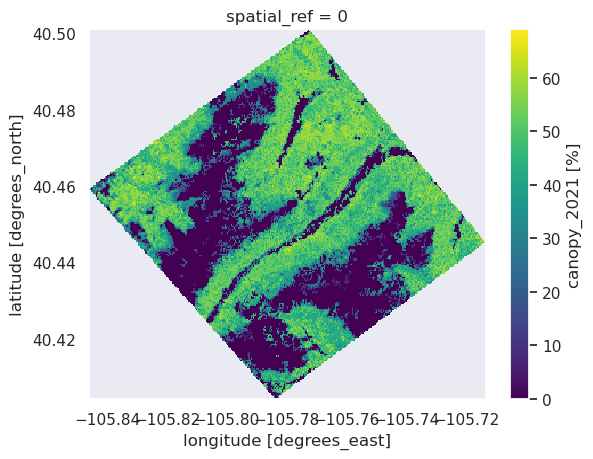

In [13]:
nlcd['canopy_2021'].plot()

In [7]:
data = assemble_data(
    tile_aoi=aoi,
    date_pairs=dates,
    flight_ids=flight_ids,
    include_layers=['coh', 'incidence', 'dem', 'nlcd', 'aorc', 'swe'], 
    fp_coh=data_dir + 'uavsar_cohs/rockmt',
    fp_inc=data_dir + 'inc_angle/',
    crs='EPSG:4326',
    res=30,
) 

2026-06-16 09:37:44,087 - INFO - Starting tile data assembly for flights <ArrowStringArray>
['32109']
Length: 1, dtype: str


2026-06-16 09:37:48,430 - INFO - Tile: loaded coherence for flights <ArrowStringArray>
['32109']
Length: 1, dtype: str in 4.322 seconds.
2026-06-16 09:37:48,600 - INFO - Tile: loaded incidence angles for flights <ArrowStringArray>
['32109']
Length: 1, dtype: str in 0.169 seconds.
2026-06-16 09:37:48,811 - INFO - boto3 not available, falling back to a DummySession.
2026-06-16 09:37:50,838 - INFO - Tile: got DEM in 2.237 seconds.
/bsuhome/julialober/miniforge3/envs/coherence_v2/lib/python3.11/site-packages/pygeoutils/pygeoutils.py:300: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  ds = xr.merge(
2026-06-16 09:37:51,107 - INFO - Tile: got NLCD ['cover_2019', 'can

In [8]:
# save the data 
data.to_zarr(data_dir + 'stacks/rmnp_box_swe', mode='w', consolidated=True)

/bsuhome/julialober/miniforge3/envs/coherence_v2/lib/python3.11/site-packages/zarr/core/dtype/npy/string.py:249: UnstableSpecificationWarning: The data type (FixedLengthUTF32(length=5, endianness='little')) does not have a Zarr V3 specification. That means that the representation of arrays saved with this data type may change without warning in a future version of Zarr Python. Arrays stored with this data type may be unreadable by other Zarr libraries. Use this data type at your own risk! Check https://github.com/zarr-developers/zarr-extensions/tree/main/data-types for the status of data type specifications for Zarr V3.
  v3_unstable_dtype_warning(self)
/bsuhome/julialober/miniforge3/envs/coherence_v2/lib/python3.11/site-packages/zarr/core/dtype/npy/string.py:249: UnstableSpecificationWarning: The data type (FixedLengthUTF32(length=13, endianness='little')) does not have a Zarr V3 specification. That means that the representation of arrays saved with this data type may change without w

## Assemble data for SLC 

In [8]:
meta = file_info[file_info['flight_path'] == 'stlake']
# meta = meta[meta['flight_num'] == '32109'] # this is the only path useful for my chosen site
summary_df = meta.pivot_table(index=['flight_path', 'flight_num'], 
                                columns='file_type', 
                                aggfunc='size', 
                                fill_value=0)
display(summary_df.join(meta.groupby(['flight_path', 'flight_num'])[['polarization', 'segment']].nunique().add_prefix('unique_')))

,,ann_slc,crosspol,geo_slc,int_pair,lkv,llh,raw_slc,unique_polarization,unique_segment
flight_path,flight_num,,,,,,,,,
stlake,27129,44,11,44,110,1,1,44,3,1


In [9]:
POL = 'VV'
int_pairs = meta[meta['file_type'] == 'int_pair']
int_pairs = int_pairs[int_pairs['polarization'] == POL]
print(f'Using only {POL} polarization.')

# get flight ids 
flight_ids = meta['flight_num'].unique()
print(f'Flight numbers: {flight_ids}')

# get all date pairs 
date_pairs_int = list(zip(int_pairs['date_reference'], int_pairs['date_secondary']))
dates = [(f"20{date[0]}", f"20{date[1]}") for date in date_pairs_int]
print(f'Number of date pairs: {len(dates)}')

# get bounding box 
filenames = [int_pairs[int_pairs['flight_num'] == f]['absolute_path'].iloc[0] for f in flight_ids]
all_bounds = [rasterio.open(f).bounds for f in filenames]
aoi = box(
    min(b[0] for b in all_bounds), # min left
    min(b[1] for b in all_bounds), # min bottom
    max(b[2] for b in all_bounds), # max right
    max(b[3] for b in all_bounds)  # max top
)

# small box for SLC
coords = Polygon([
    (-111.7332140938517, 40.6079909188825),
    (-111.7307874732357, 40.58585096349459),
    (-111.6857755957641, 40.58703464363237),
    (-111.6873712400506, 40.60845482790766),
    (-111.7332140938517, 40.6079909188825)
])

# Create the 2D Polygon
aoi = Polygon(coords)

print(f'AOI bounding box: {aoi}')

Using only VV polarization.
Flight numbers: <ArrowStringArray>
['27129']
Length: 1, dtype: str
Number of date pairs: 55
AOI bounding box: POLYGON ((-111.7332140938517 40.6079909188825, -111.7307874732357 40.58585096349459, -111.6857755957641 40.58703464363237, -111.6873712400506 40.60845482790766, -111.7332140938517 40.6079909188825))


In [10]:
METRES_PER_DEGREE_AT_45_LAT: float = 111320.0 * math.cos(math.radians(45.0))
res = 30 
res_grid = res / METRES_PER_DEGREE_AT_45_LAT
ref_grid = make_reference_grid(aoi=aoi, crs='EPSG:4326', resolution=res_grid)

In [10]:
cohs_1x1 = get_uavsar_coherence(
    tile_aoi=aoi,
    date_pairs=validate_date_pairs(dates),
    flight_ids=flight_ids,
    crs='EPSG:4326',
    tile_ref_grid=ref_grid,
    fp=data_dir + 'uavsar_cohs_cropped/stlake/',
)
cohs_1x1

<xarray.Dataset> Size: 2MB
Dimensions:      (flight_id: 1, pair: 55, y: 60, x: 125)
Coordinates:
  * flight_id    (flight_id) StringDType(na_object=nan) 16B '27129'
  * pair         (pair) <U13 3kB '200213_200312' ... '200131_210322'
  * y            (y) float64 480B 40.61 40.61 40.61 40.61 ... 40.59 40.59 40.59
  * x            (x) float64 1kB -111.7 -111.7 -111.7 ... -111.7 -111.7 -111.7
    spatial_ref  int64 8B 0
Data variables:
    coherence    (flight_id, pair, y, x) float32 2MB 0.4494 0.4554 ... nan nan

In [11]:
cohs_2x8 = get_uavsar_coherence(
    tile_aoi=aoi,
    date_pairs=validate_date_pairs(dates),
    flight_ids=flight_ids,
    crs='EPSG:4326',
    tile_ref_grid=ref_grid,
    fp=data_dir + 'uavsar_cohs/stlake/',
)
cohs_2x8

<xarray.Dataset> Size: 2MB
Dimensions:      (flight_id: 1, pair: 55, y: 60, x: 125)
Coordinates:
  * flight_id    (flight_id) StringDType(na_object=nan) 16B '27129'
  * pair         (pair) <U13 3kB '200213_200312' ... '200131_210322'
  * y            (y) float64 480B 40.61 40.61 40.61 40.61 ... 40.59 40.59 40.59
  * x            (x) float64 1kB -111.7 -111.7 -111.7 ... -111.7 -111.7 -111.7
    spatial_ref  int64 8B 0
Data variables:
    coherence    (flight_id, pair, y, x) float32 2MB 0.3119 0.3171 ... 0.2187

In [11]:
cohs_VH = get_uavsar_coherence(
    tile_aoi=aoi,
    date_pairs=validate_date_pairs(dates),
    flight_ids=flight_ids,
    crs='EPSG:4326',
    tile_ref_grid=ref_grid,
    fp=data_dir + 'uavsar_cohs_cropped/stlake/',
    pol = 'VH'
)
cohs_VH

<xarray.Dataset> Size: 2MB
Dimensions:      (flight_id: 1, pair: 55, y: 60, x: 125)
Coordinates:
  * flight_id    (flight_id) StringDType(na_object=nan) 16B '27129'
  * pair         (pair) <U13 3kB '200213_200312' ... '200131_210322'
  * y            (y) float64 480B 40.61 40.61 40.61 40.61 ... 40.59 40.59 40.59
  * x            (x) float64 1kB -111.7 -111.7 -111.7 ... -111.7 -111.7 -111.7
    spatial_ref  int64 8B 0
Data variables:
    coherence    (flight_id, pair, y, x) float32 2MB 0.3932 0.4742 ... nan nan

In [12]:
cohs_VH.to_zarr(data_dir + 'stacks/slc_box_1x1_cohVH', mode='w', consolidated=True)

/bsuhome/julialober/miniforge3/envs/coherence_v2/lib/python3.11/site-packages/zarr/core/dtype/npy/string.py:249: UnstableSpecificationWarning: The data type (FixedLengthUTF32(length=5, endianness='little')) does not have a Zarr V3 specification. That means that the representation of arrays saved with this data type may change without warning in a future version of Zarr Python. Arrays stored with this data type may be unreadable by other Zarr libraries. Use this data type at your own risk! Check https://github.com/zarr-developers/zarr-extensions/tree/main/data-types for the status of data type specifications for Zarr V3.
  v3_unstable_dtype_warning(self)
/bsuhome/julialober/miniforge3/envs/coherence_v2/lib/python3.11/site-packages/zarr/core/dtype/npy/string.py:249: UnstableSpecificationWarning: The data type (FixedLengthUTF32(length=13, endianness='little')) does not have a Zarr V3 specification. That means that the representation of arrays saved with this data type may change without w

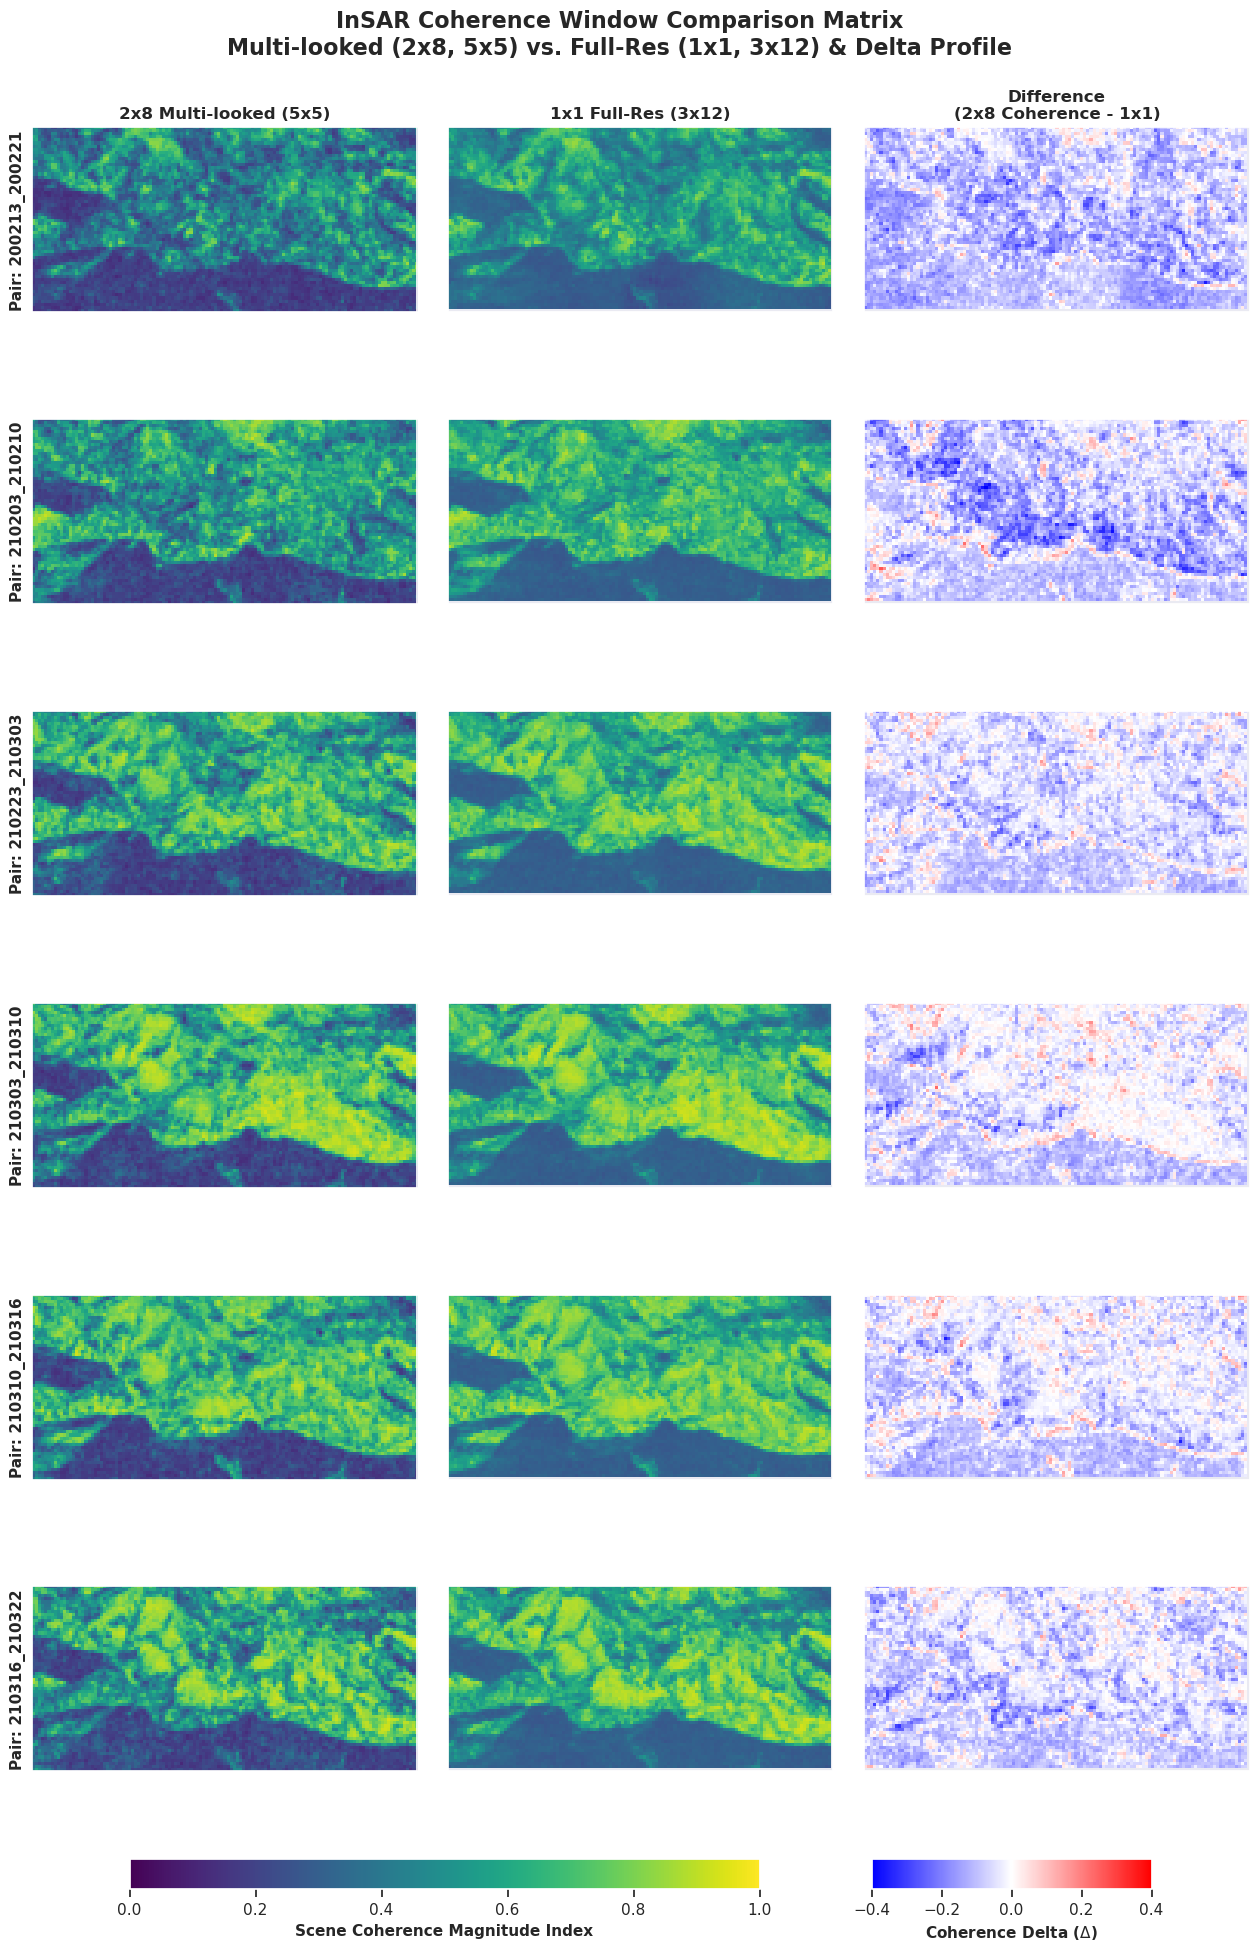

In [13]:
import matplotlib.cm as cm
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

# ==============================================================================
# 1. DEFINE TARGET PAIRS & SUBSET DATASETS
# ==============================================================================
target_pairs = [
    "200213_200221",
    "210203_210210",
    "210223_210303",
    "210303_210310",
    "210310_210316",
    "210316_210322",
]

# Isolate the exact pairs and compress spatial dimensions by averaging over flight tracks
# (Assuming datasets have dimensions matching: pair, flight_id, y, x)
coh_2x8 = cohs_2x8["coherence"].sel(pair=target_pairs).mean(dim="flight_id")
coh_1x1 = cohs_1x1["coherence"].sel(pair=target_pairs).mean(dim="flight_id")

# Calculate the spatial coherence variation map
# Positive values = 2x8 multilooked window preserved higher scene coherence
# Negative values = 1x1 full-res window preserved higher scene coherence
coh_diff = coh_2x8 - coh_1x1

# ==============================================================================
# 2. INITIALIZE 6 ROWS BY 3 COLUMNS GRAPHICS GRID
# ==============================================================================
fig, axes = plt.subplots(
    nrows=6, ncols=3, figsize=(14, 20), sharex=True, sharey=True
)
fig.suptitle(
    "InSAR Coherence Window Comparison Matrix\nMulti-looked (2x8, 5x5) vs. Full-Res (1x1, 3x12) & Delta Profile",
    fontsize=16,
    fontweight="bold",
    y=0.98,
)

# Loop through rows (pairs) and map the spatial arrays
for row_idx, pair_name in enumerate(target_pairs):

    # Extract 2D spatial slices for the current timeline row
    data_2x8 = coh_2x8.sel(pair=pair_name)
    data_1x1 = coh_1x1.sel(pair=pair_name)
    data_diff = coh_diff.sel(pair=pair_name)

    # --- Column 1: 2x8 Coherence ---
    ax_left = axes[row_idx, 0]
    im_left = ax_left.imshow(
        data_2x8.values, vmin=0, vmax=1, cmap="viridis", origin="upper"
    )
    if row_idx == 0:
        ax_left.set_title("2x8 Multi-looked (5x5)", fontsize=12, fontweight="bold")
    ax_left.set_ylabel(f"Pair: {pair_name}", fontsize=11, fontweight="bold")

    # --- Column 2: 1x1 Coherence ---
    ax_mid = axes[row_idx, 1]
    im_mid = ax_mid.imshow(
        data_1x1.values, vmin=0, vmax=1, cmap="viridis", origin="upper"
    )
    if row_idx == 0:
        ax_mid.set_title("1x1 Full-Res (3x12)", fontsize=12, fontweight="bold")

    # --- Column 3: Absolute Coherence Difference ---
    ax_right = axes[row_idx, 2]
    # Diverging colormap centered at exactly 0.0 variance
    im_diff = ax_right.imshow(
        data_diff.values, vmin=-0.4, vmax=0.4, cmap="bwr", origin="upper"
    )
    if row_idx == 0:
        ax_right.set_title("Difference\n(2x8 Coherence - 1x1)", fontsize=12, fontweight="bold")

    # Clean grid ticks to avoid map clutter
    for ax in [ax_left, ax_mid, ax_right]:
        ax.set_xticks([])
        ax.set_yticks([])

# ==============================================================================
# 3. COMPACT COLORBAR INTEGRATION
# ==============================================================================
# Add colorbar for the standard absolute coherence scales (Columns 1 & 2)
cbar_ax_coherence = fig.add_axes([0.15, 0.04, 0.45, 0.015])  # [left, bottom, width, height]
cb_coh = fig.colorbar(im_left, cbar_ax_coherence, orientation="horizontal")
cb_coh.set_label("Scene Coherence Magnitude Index", fontsize=11, fontweight="semibold")

# Add colorbar for the diverging difference maps (Column 3)
cbar_ax_diff = fig.add_axes([0.68, 0.04, 0.20, 0.015])
cb_diff = fig.colorbar(im_diff, cbar_ax_diff, orientation="horizontal")
cb_diff.set_label("Coherence Delta ($\Delta$)", fontsize=11, fontweight="semibold")

# Finalize adjustments manually to leave space below for colorbars
plt.subplots_adjust(left=0.08, right=0.95, top=0.94, bottom=0.08, hspace=0.12, wspace=0.08)
plt.show()

In [20]:
cohs_1x1.to_zarr(data_dir + 'stacks/slc_box_1x1_coh', mode='w', consolidated=True)

/bsuhome/julialober/miniforge3/envs/coherence_v2/lib/python3.11/site-packages/zarr/core/dtype/npy/string.py:249: UnstableSpecificationWarning: The data type (FixedLengthUTF32(length=5, endianness='little')) does not have a Zarr V3 specification. That means that the representation of arrays saved with this data type may change without warning in a future version of Zarr Python. Arrays stored with this data type may be unreadable by other Zarr libraries. Use this data type at your own risk! Check https://github.com/zarr-developers/zarr-extensions/tree/main/data-types for the status of data type specifications for Zarr V3.
  v3_unstable_dtype_warning(self)
/bsuhome/julialober/miniforge3/envs/coherence_v2/lib/python3.11/site-packages/zarr/core/dtype/npy/string.py:249: UnstableSpecificationWarning: The data type (FixedLengthUTF32(length=13, endianness='little')) does not have a Zarr V3 specification. That means that the representation of arrays saved with this data type may change without w

In [20]:
nlcd = get_nlcd_layers(
    tile_aoi=aoi,
    crs='EPSG:4326',
    years={'cover': [2021], 'canopy': [2021]},
    tile_ref_grid=ref_grid,
)
nlcd

/bsuhome/julialober/miniforge3/envs/coherence_v2/lib/python3.11/site-packages/pygeoutils/pygeoutils.py:300: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  ds = xr.merge(


<xarray.Dataset> Size: 39kB
Dimensions:      (x: 125, y: 60)
Coordinates:
  * x            (x) float64 1kB -111.7 -111.7 -111.7 ... -111.7 -111.7 -111.7
  * y            (y) float64 480B 40.61 40.61 40.61 40.61 ... 40.59 40.59 40.59
    spatial_ref  int64 8B 0
Data variables:
    cover_2021   (y, x) uint8 8kB 127 127 127 127 127 ... 127 127 127 127 127
    canopy_2021  (y, x) float32 30kB nan nan nan nan nan ... nan nan nan nan nan
Attributes:
    TIFFTAG_XRESOLUTION:     1
    TIFFTAG_YRESOLUTION:     1
    TIFFTAG_RESOLUTIONUNIT:  1 (unitless)
    AREA_OR_POINT:           Area
    _FillValue:              255
    scale_factor:            1.0
    add_offset:              0.0

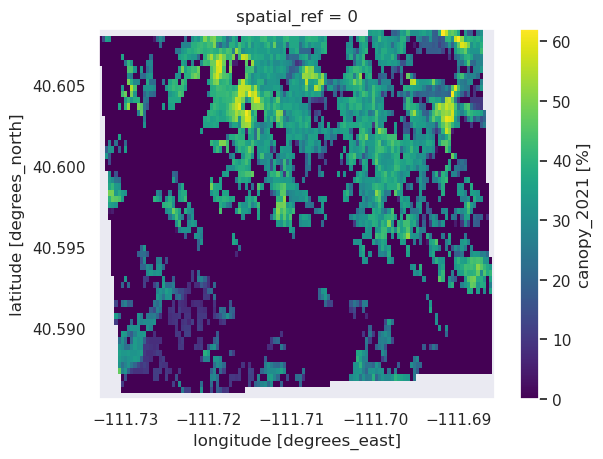

In [21]:
nlcd['canopy_2021'].plot()

In [18]:
import rasterio

# 1. Open the environment wrapper at the very top level

In [19]:
with rasterio.Env(CURL_CA_BUNDLE=certifi.where(), SSL_CERT_FILE=certifi.where()):
    data = assemble_data(
        tile_aoi=aoi,
        date_pairs=dates,
        flight_ids=flight_ids,
        include_layers=['coh', 'incidence', 'dem', 'nlcd', 'aorc', 'swe'], 
        fp_coh=data_dir + 'uavsar_cohs_cropped/stlake',
        fp_inc=data_dir + 'inc_angle/',
        crs='EPSG:4326',
        res=30,
    ) 

py3dep.get_dem failed: CURL error: SSL certificate OpenSSL verify result: unable to get local issuer certificate (20)


RasterioIOError: CURL error: SSL certificate OpenSSL verify result: unable to get local issuer certificate (20)

In [13]:
# save the data 
data.to_zarr(data_dir + 'stacks/slc_box_swe', mode='w', consolidated=True)

/bsuhome/julialober/miniforge3/envs/coherence_v2/lib/python3.11/site-packages/zarr/core/dtype/npy/string.py:249: UnstableSpecificationWarning: The data type (FixedLengthUTF32(length=5, endianness='little')) does not have a Zarr V3 specification. That means that the representation of arrays saved with this data type may change without warning in a future version of Zarr Python. Arrays stored with this data type may be unreadable by other Zarr libraries. Use this data type at your own risk! Check https://github.com/zarr-developers/zarr-extensions/tree/main/data-types for the status of data type specifications for Zarr V3.
  v3_unstable_dtype_warning(self)
/bsuhome/julialober/miniforge3/envs/coherence_v2/lib/python3.11/site-packages/zarr/core/dtype/npy/string.py:249: UnstableSpecificationWarning: The data type (FixedLengthUTF32(length=13, endianness='little')) does not have a Zarr V3 specification. That means that the representation of arrays saved with this data type may change without w

In [24]:
data

<xarray.Dataset> Size: 38MB
Dimensions:          (x: 125, y: 60, flight_id: 1, pair: 55)
Coordinates:
  * x                (x) float64 1kB -111.7 -111.7 -111.7 ... -111.7 -111.7
  * y                (y) float64 480B 40.61 40.61 40.61 ... 40.59 40.59 40.59
  * flight_id        (flight_id) StringDType(na_object=nan) 16B '27129'
  * pair             (pair) <U13 3kB '200131_200213' ... '210316_210322'
    spatial_ref      int64 8B 0
    band             int64 8B 1
Data variables: (12/16)
    coherence        (flight_id, pair, y, x) float32 2MB 0.3354 ... 0.1951
    incidence_angle  (flight_id, y, x) float64 60kB 39.69 32.0 ... 107.4 111.1
    elevation        (y, x) float32 30kB nan nan nan nan nan ... nan nan nan nan
    cover_2019       (y, x) float32 30kB 127.0 127.0 127.0 ... 127.0 127.0 127.0
    canopy_2019      (y, x) float32 30kB nan nan nan nan nan ... nan nan nan nan
    mean_temp        (pair, y, x) float64 3MB nan nan nan nan ... nan nan nan
    ...               ...
    avg_rain         (pair, y, x) float64 3MB nan nan nan nan ... nan nan nan
    total_snow       (pair, y, x) float64 3MB nan nan nan nan ... nan nan nan
    avg_snow         (pair, y, x) float64 3MB nan nan nan nan ... nan nan nan
    acq_day_precip   (pair, y, x) float64 3MB nan nan nan nan ... nan nan nan
    mean_wind        (pair, y, x) float64 3MB nan nan nan nan ... nan nan nan
    max_wind         (pair, y, x) float64 3MB nan nan nan nan ... nan nan nan

## Assemble data for Grand Mesa

In [4]:
# download data from earthaccess 
import earthaccess as ea

auth = ea.login()
if not auth.authenticated:
    auth.login(strategy="interactive", persist=True)

In [15]:
from rasterio.enums import Resampling
import contextily as ctx

In [32]:
target_granules = [
    "_SD_"
    # "SNEX20_GM_Lidar_SDsubset_20200201_20200202_v01.0.tif"
]
grans = ea.search_data(
    short_name='SNEX20_GM_Lidar',
    cloud_hosted=True,
    # temporal=('2021-03-18', '2021-03-19'),
)
grans = [
    g for g in grans 
    if any(target in (g.path if hasattr(g, 'path') else str(g)) for target in target_granules)
]
file = ea.open(grans)[0]


/bsuhome/julialober/miniforge3/envs/coherence_v2/lib/python3.11/site-packages/earthaccess/results.py:343: FutureWarning: As of version 1.0, `DataGranule.size` will be accessed as an attribute; e.g. use `DataCollection.size` **not** `DataCollection.size()`
  self["size"] = self.size()
/bsuhome/julialober/miniforge3/envs/coherence_v2/lib/python3.11/site-packages/earthaccess/results.py:364: FutureWarning: As of version 1.0, `DataGranule.size` will be accessed as an attribute; e.g. use `DataCollection.size` **not** `DataCollection.size()`
  Size(MB): {self.size()}
/bsuhome/julialober/miniforge3/envs/coherence_v2/lib/python3.11/site-packages/earthaccess/store.py:516: FutureWarning: As of version 1.0, `DataGranule.size` will be accessed as an attribute; e.g. use `DataCollection.size` **not** `DataCollection.size()`
  total_size = round(sum([granule.size() for granule in granules]) / 1024, 2)
QUEUEING TASKS | : 100%|██████████| 1/1 [00:00<00:00, 2423.05it/s]
PROCESSING TASKS | : 100%|████████

In [33]:

da_lidar = rxa.open_rasterio(file, chunks={'x': 2000, 'y': 2000}).squeeze()
da_lidar = da_lidar.where(da_lidar >= 0) 
# da_lidar[da_lidar <= 0] = np.nan


target_crs = "EPSG:4326"
target_resolution = 0.000045

logger.info(f"Reprojecting and downsampling Lidar to 5m resolution in {target_crs}...")
da_lidar_5m = da_lidar.rio.reproject(
    dst_crs=target_crs,
    resolution=target_resolution,
    resampling=Resampling.average
)

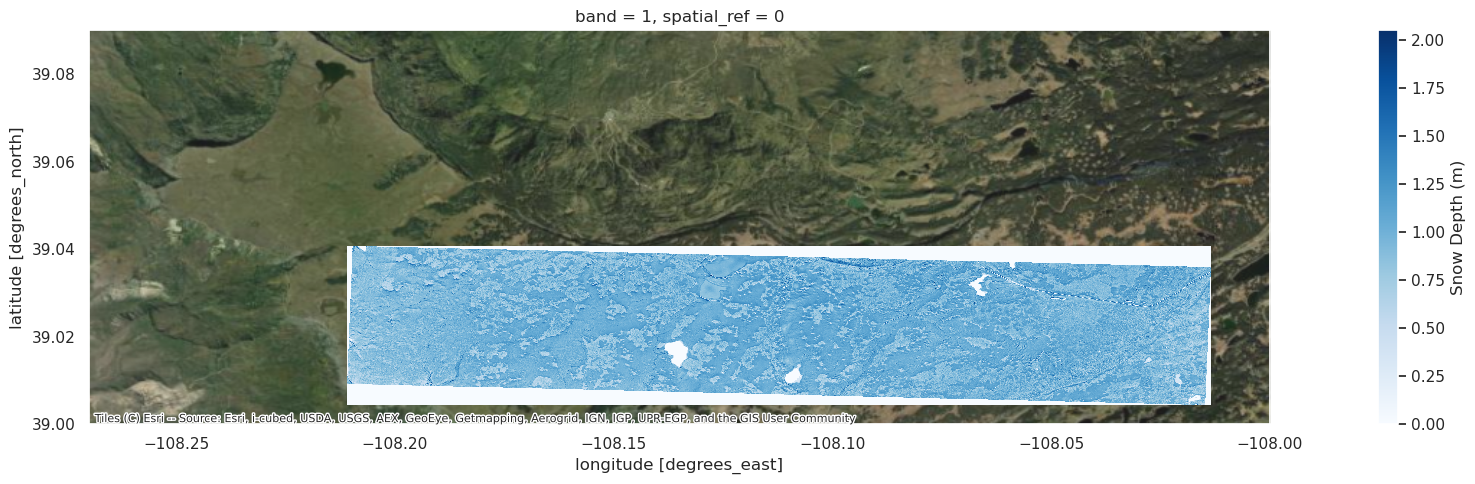

In [34]:
fig, ax = plt.subplots(figsize=(22, 5))

da_lidar_5m.plot(
        ax=ax, 
        # x='x',
        # y='y',
        cmap='Blues', 
        cbar_kwargs={'label': 'Snow Depth (m)'},
        # alpha=1,
        zorder=2,
    )
ctx.add_basemap(
        ax, 
        crs=target_crs, 
        source=ctx.providers.Esri.WorldImagery,
        alpha=0.9
    )

ax.set_ylim((39, 39.09))
ax.set_xlim((-108.27, -108))
ax.set_aspect("equal")

plt.tight_layout()
plt.show()

# grans

In [6]:
target_granules = [
    "MW"
    # "SNEX_Met_MW_final_output.csv"
]
grans = earthaccess.search_data(
    short_name='SNEX_Met',
    cloud_hosted=True,
    # temporal=('2021-03-18', '2021-03-19'),
)
grans = [
    g for g in grans 
    if any(target in (g.path if hasattr(g, 'path') else str(g)) for target in target_granules)
]
files = ea.open(grans)
# grans = grans[1]
grans

QUEUEING TASKS | : 100%|██████████| 1/1 [00:00<00:00, 3352.76it/s]
PROCESSING TASKS | : 100%|██████████| 1/1 [00:01<00:00,  1.23s/it]
COLLECTING RESULTS | : 100%|██████████| 1/1 [00:00<00:00, 22429.43it/s]


[Collection: {'EntryTitle': 'SnowEx Meteorological Station Measurements from Grand Mesa, CO V001'}
 Spatial coverage: {'HorizontalSpatialDomain': {'Geometry': {'Points': [{'Longitude': -108.21399, 'Latitude': 39.03388}]}}}
 Temporal coverage: {'RangeDateTime': {'BeginningDateTime': '2016-10-09T00:00:01.000Z', 'EndingDateTime': '2022-08-30T23:59:59.000Z'}}
 Size(MB): 7.8231
 Data: ['https://data.nsidc.earthdatacloud.nasa.gov/nsidc-cumulus-prod-protected/SNOWEX/SNEX_Met/1/2016/10/09/SNEX_Met_MW_final_output.csv']]

In [7]:
meta = file_info[file_info['flight_path'] == 'grmesa']
# meta = meta[meta['flight_num'] == '32109'] # this is the only path useful for my chosen site
summary_df = meta.pivot_table(index=['flight_path', 'flight_num'], 
                                columns='file_type', 
                                aggfunc='size', 
                                fill_value=0)
display(summary_df.join(meta.groupby(['flight_path', 'flight_num'])[['polarization', 'segment']].nunique().add_prefix('unique_')))

ann_slc  crosspol  geo_slc  int_pair  lkv  llh  \
flight_path flight_num                                                   
grmesa      09305            20         5       20        20    1    1   
            27416            48        12       48       132    1    1   

                        raw_slc  unique_polarization  unique_segment  
flight_path flight_num                                                
grmesa      09305            20                    3               1  
            27416            48                    3               1

In [11]:
POL = 'VV'
int_pairs = meta[meta['file_type'] == 'int_pair']
int_pairs = int_pairs[int_pairs['polarization'] == POL]
print(f'Using only {POL} polarization.')

# get flight ids 
flight_ids = meta['flight_num'].unique()
print(f'Flight numbers: {flight_ids}')

# get all date pairs 
date_pairs_int = list(zip(int_pairs['date_reference'], int_pairs['date_secondary']))
dates = [(f"20{date[0]}", f"20{date[1]}") for date in date_pairs_int]
print(f'Number of date pairs: {len(dates)}')

# get bounding box 
filenames = [int_pairs[int_pairs['flight_num'] == f]['absolute_path'].iloc[0] for f in flight_ids]
all_bounds = [rasterio.open(f).bounds for f in filenames]
aoi = box(
    min(b[0] for b in all_bounds), # min left
    min(b[1] for b in all_bounds), # min bottom
    max(b[2] for b in all_bounds), # max right
    max(b[3] for b in all_bounds)  # max top
)

# small box for SLC
coords = Polygon([
    (-108.228762437303, 38.99558424369346),
    (-108.1334078731154, 38.99558424369346),
    (-108.1334078731154, 39.05171182446141),
    (-108.228762437303, 39.05171182446141),
    (-108.228762437303, 38.99558424369346)
])
coords = Polygon([
    (-108.21093, 39.00796),
    (-108.21093, 39.00796),
    (-108.15775, 39.04071),
    (-108.21093, 39.04071),
    (-108.21093, 39.0079)
])


# Create the 2D Polygon
aoi = Polygon(coords)

print(f'AOI bounding box: {aoi}')

Using only VV polarization.
Flight numbers: <ArrowStringArray>
['09305', '27416']
Length: 2, dtype: str
Number of date pairs: 76
AOI bounding box: POLYGON ((-108.21093 39.00796, -108.21093 39.00796, -108.15775 39.04071, -108.21093 39.04071, -108.21093 39.0079, -108.21093 39.00796))


In [12]:
METRES_PER_DEGREE_AT_45_LAT: float = 111320.0 * math.cos(math.radians(45.0))
res = 30 
res_grid = res / METRES_PER_DEGREE_AT_45_LAT
ref_grid = make_reference_grid(aoi=aoi, crs='EPSG:4326', resolution=res_grid)

In [13]:
cohs_VV = get_uavsar_coherence(
    tile_aoi=aoi,
    date_pairs=validate_date_pairs(dates),
    flight_ids=flight_ids,
    crs='EPSG:4326',
    tile_ref_grid=ref_grid,
    fp=data_dir + 'uavsar_cohs_cropped/grmesa/',
    pol = 'VV'
)
cohs_VV

No coherence file found for 09305 on 200201_200219. Padding with NaNs.
No coherence file found for 09305 on 200212_200226. Padding with NaNs.
No coherence file found for 09305 on 200201_200312. Padding with NaNs.


No coherence file found for 09305 on 200219_200312. Padding with NaNs.
No coherence file found for 09305 on 200201_200226. Padding with NaNs.
No coherence file found for 09305 on 200212_200312. Padding with NaNs.
No coherence file found for 09305 on 200201_210210. Padding with NaNs.
No coherence file found for 09305 on 200212_210316. Padding with NaNs.
No coherence file found for 09305 on 200212_200312. Padding with NaNs.
No coherence file found for 09305 on 200226_210310. Padding with NaNs.
No coherence file found for 09305 on 210127_210322. Padding with NaNs.
No coherence file found for 09305 on 200212_210303. Padding with NaNs.
No coherence file found for 09305 on 200201_210303. Padding with NaNs.
No coherence file found for 09305 on 200219_210322. Padding with NaNs.
No coherence file found for 09305 on 210127_210203. Padding with NaNs.
No coherence file found for 09305 on 200201_200219. Padding with NaNs.
No coherence file found for 09305 on 200201_210310. Padding with NaNs.
No coh

<xarray.Dataset> Size: 7MB
Dimensions:      (flight_id: 2, pair: 76, y: 87, x: 140)
Coordinates:
  * flight_id    (flight_id) StringDType(na_object=nan) 32B '09305' '27416'
  * pair         (pair) <U13 4kB '200201_200219' ... '210127_210303'
  * y            (y) float64 696B 39.04 39.04 39.04 39.04 ... 39.01 39.01 39.01
  * x            (x) float64 1kB -108.2 -108.2 -108.2 ... -108.2 -108.2 -108.2
    spatial_ref  int64 8B 0
Data variables:
    coherence    (flight_id, pair, y, x) float32 7MB nan nan nan ... nan nan nan

## Reopen saved data 

In [25]:
all_data = xr.open_zarr(data_dir + 'stacks/slc_box_swe')

In [26]:
old_data = data

In [14]:
single_year_pairs = [
    f'{p[0][2:]}_{p[1][2:]}' for p in dates 
    if p[0][2:4] == p[1][2:4]
]

print(single_year_pairs)

data = data.sel(pair=single_year_pairs)

['200213_200312', '210203_210316', '200221_200312', '210223_210316', '210203_210310', '210310_210316', '210210_210303', '210210_210310', '210223_210303', '210203_210223', '210203_210303', '210310_210322', '210223_210310', '200131_200312', '210316_210322', '210210_210322', '210303_210316', '210203_210210', '200131_200221', '200131_200213', '200213_200221', '210203_210322', '210303_210310', '210303_210322', '210210_210316', '210223_210322', '210210_210223']


In [15]:
data = data.where(data['elevation'].notnull())

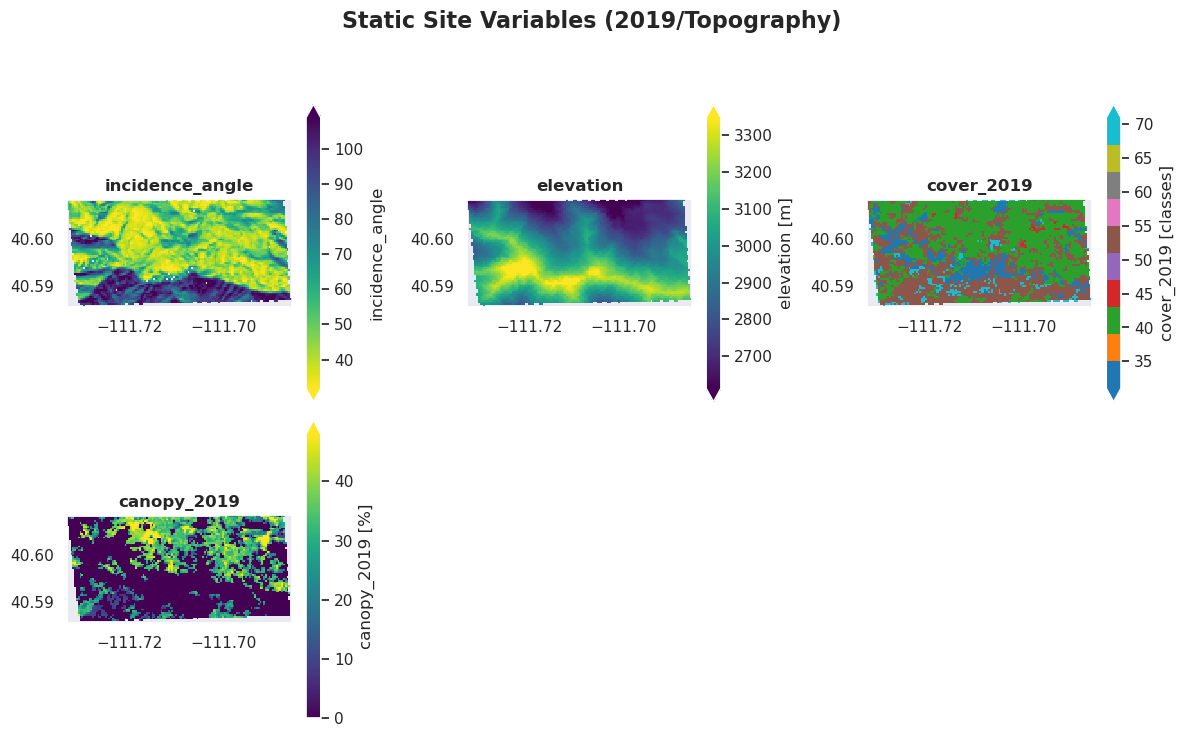

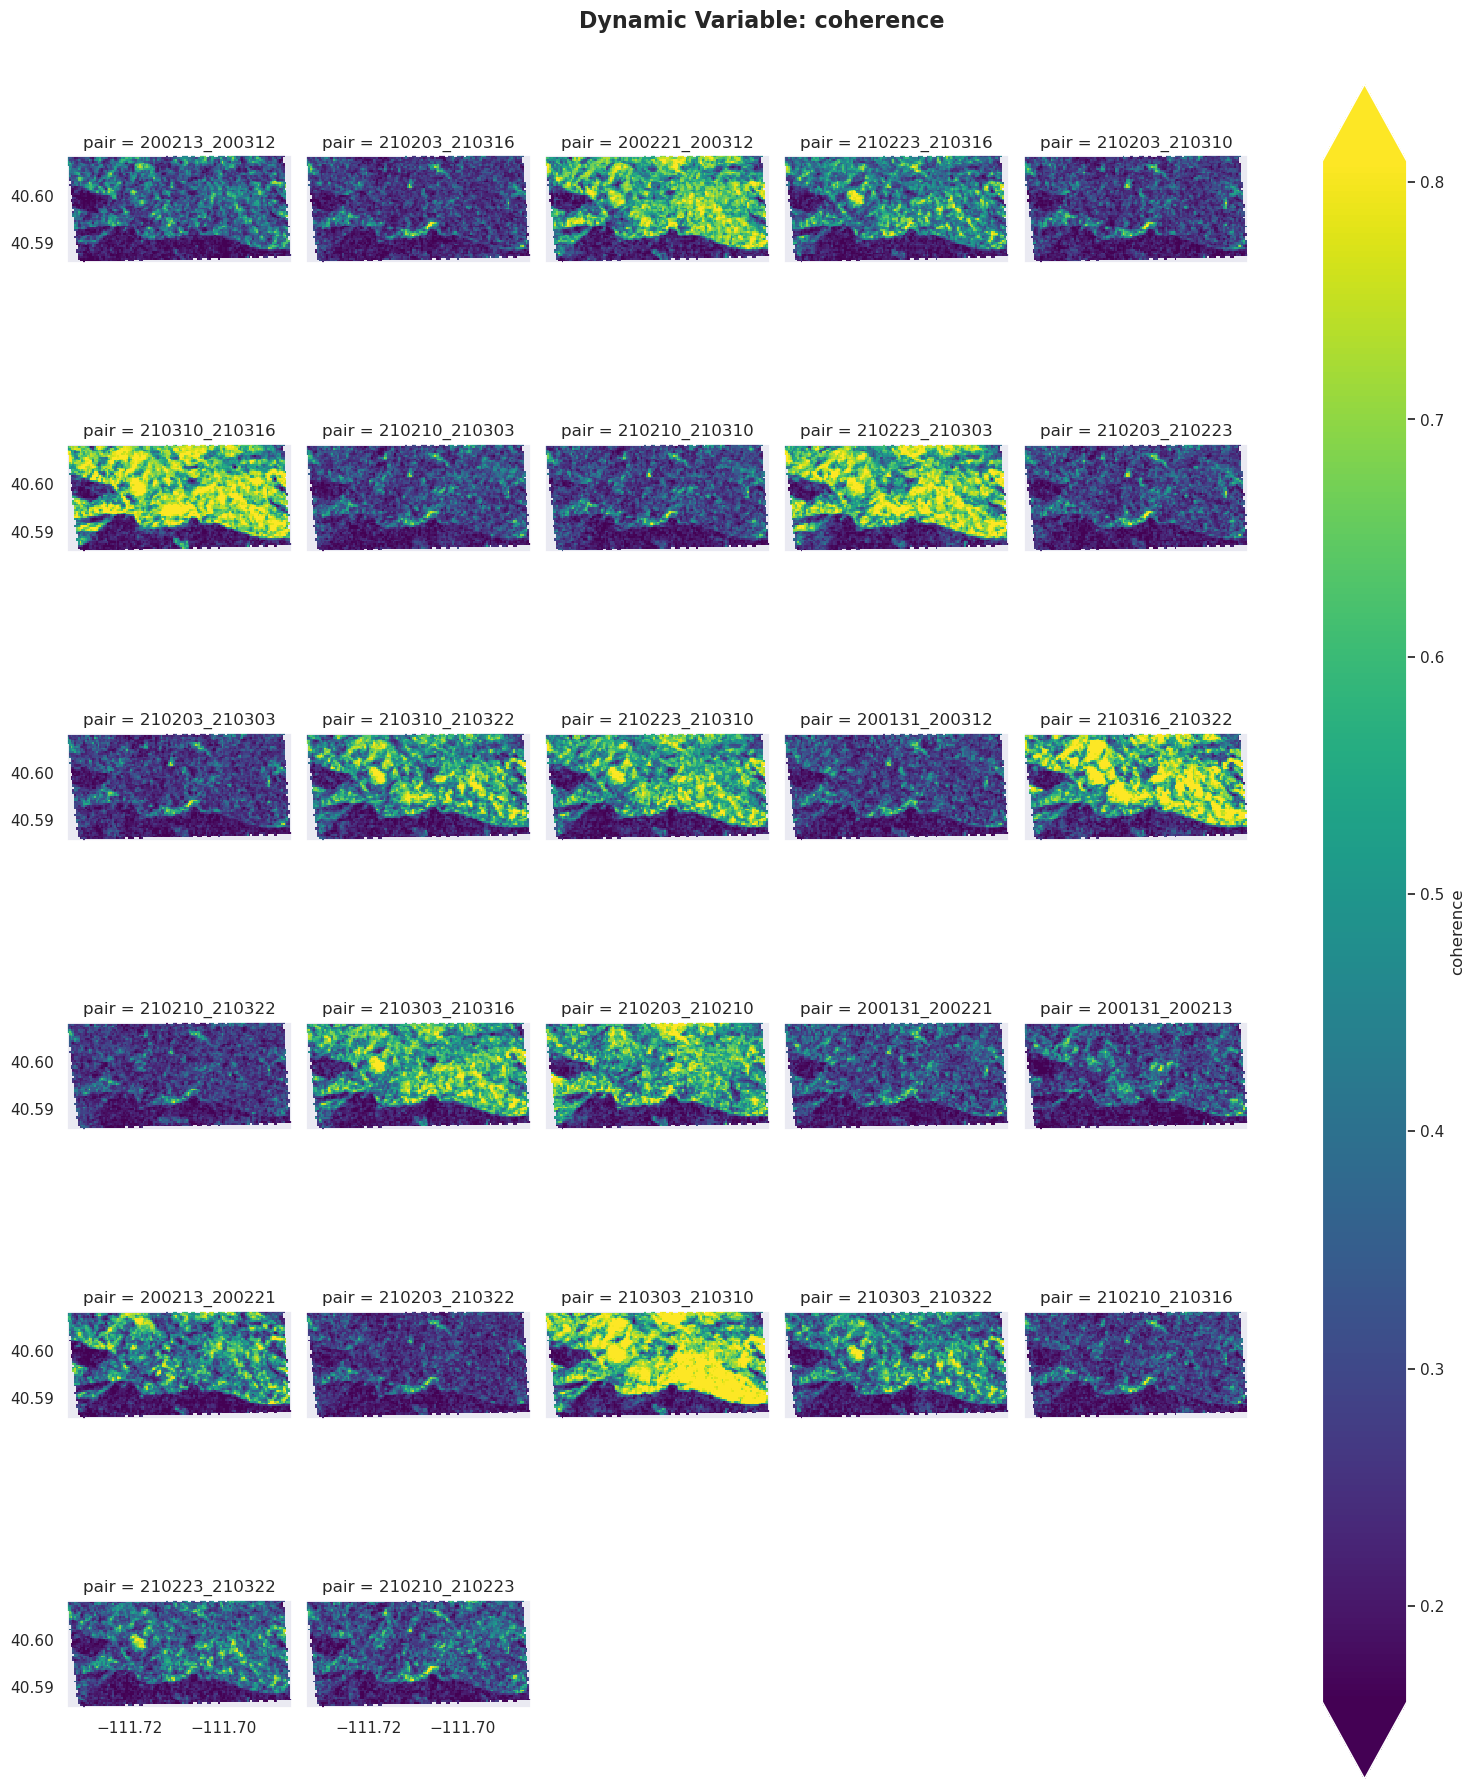

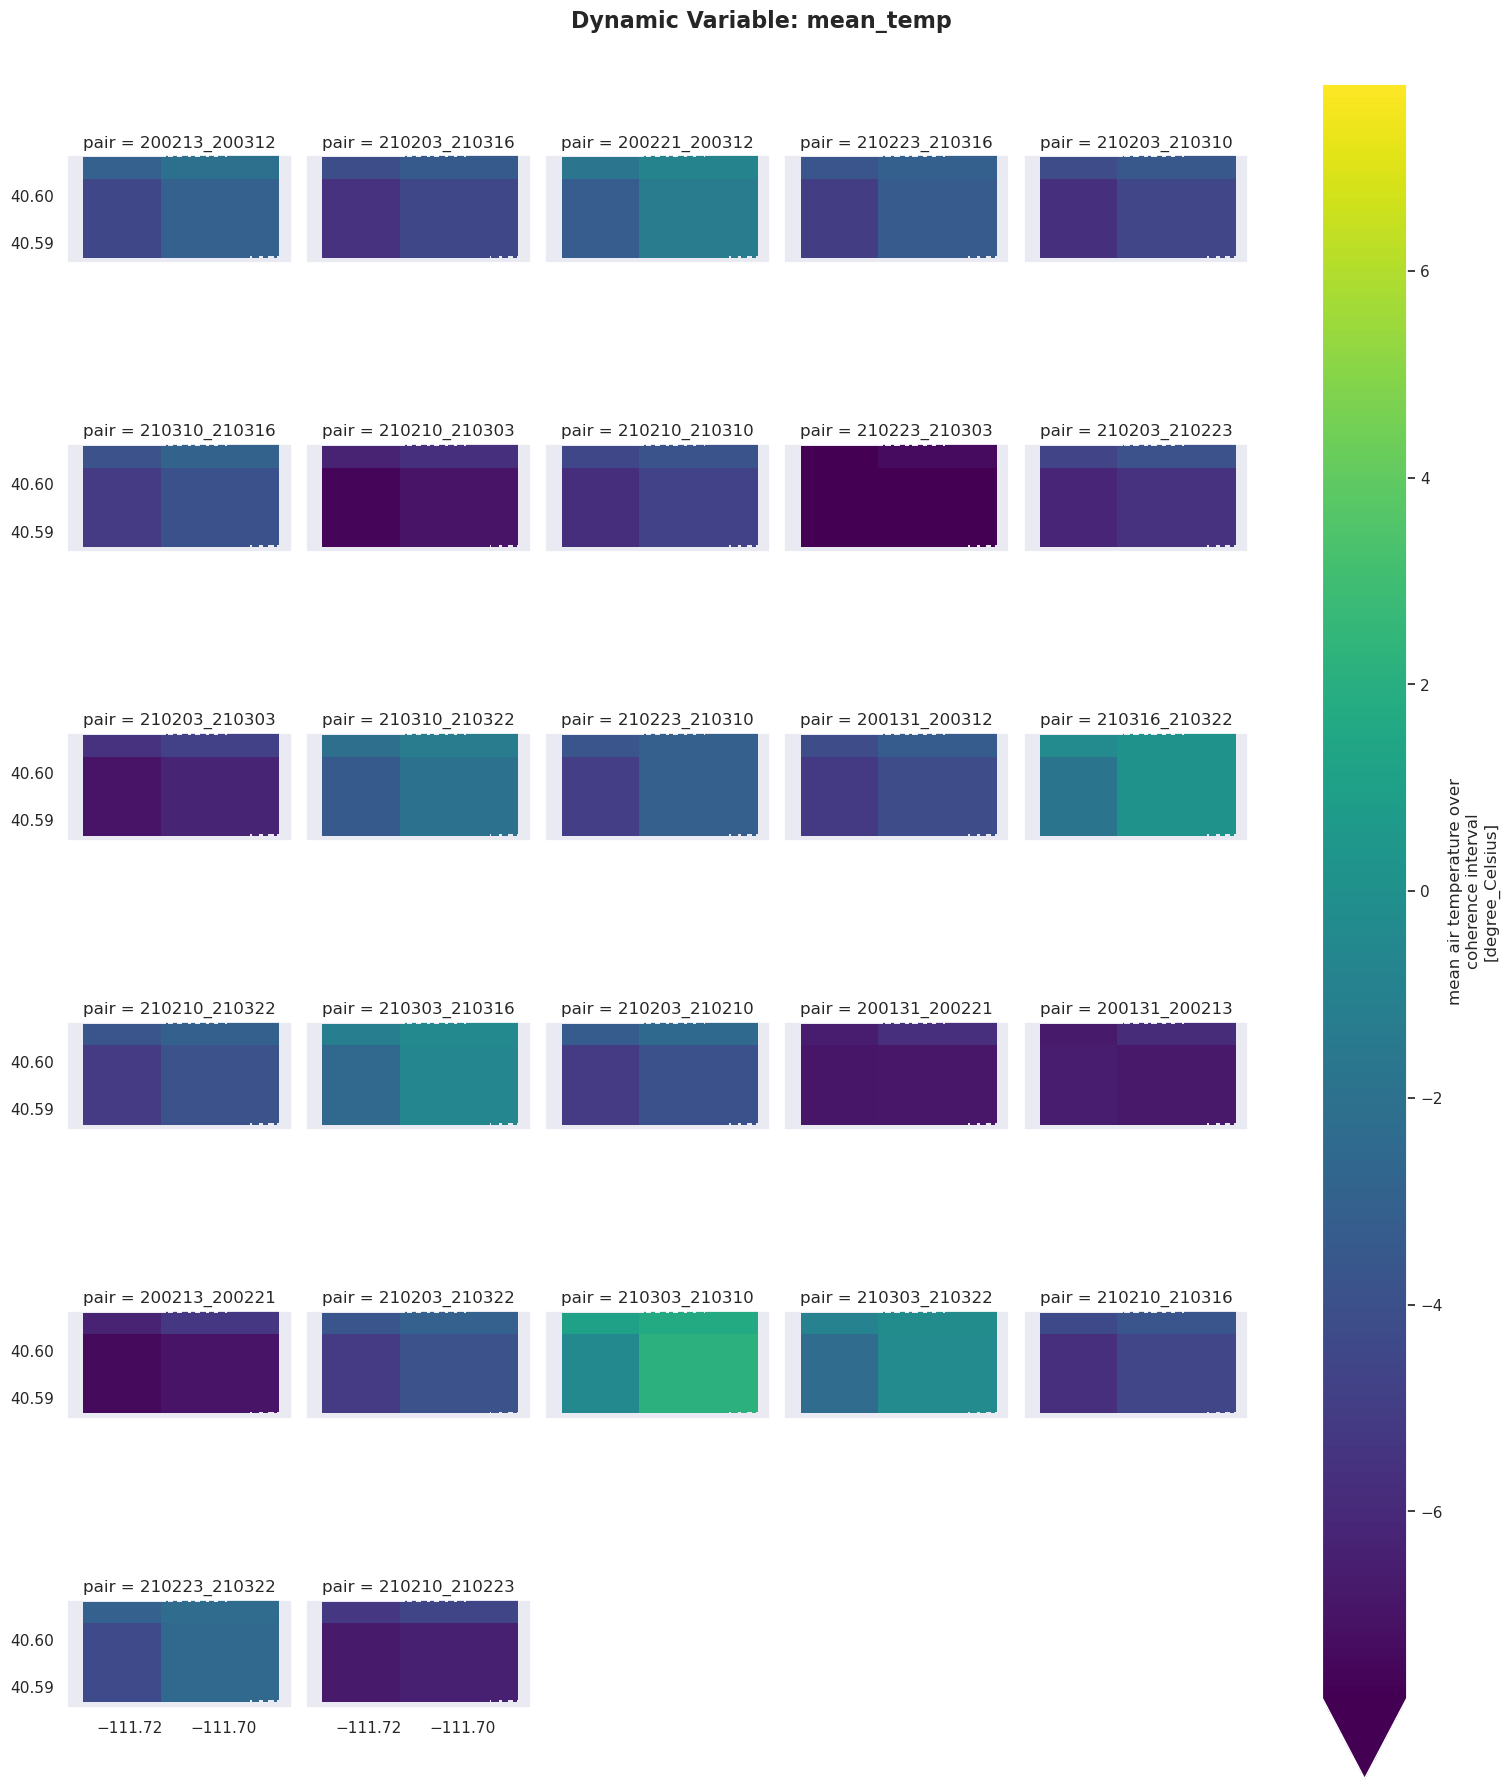

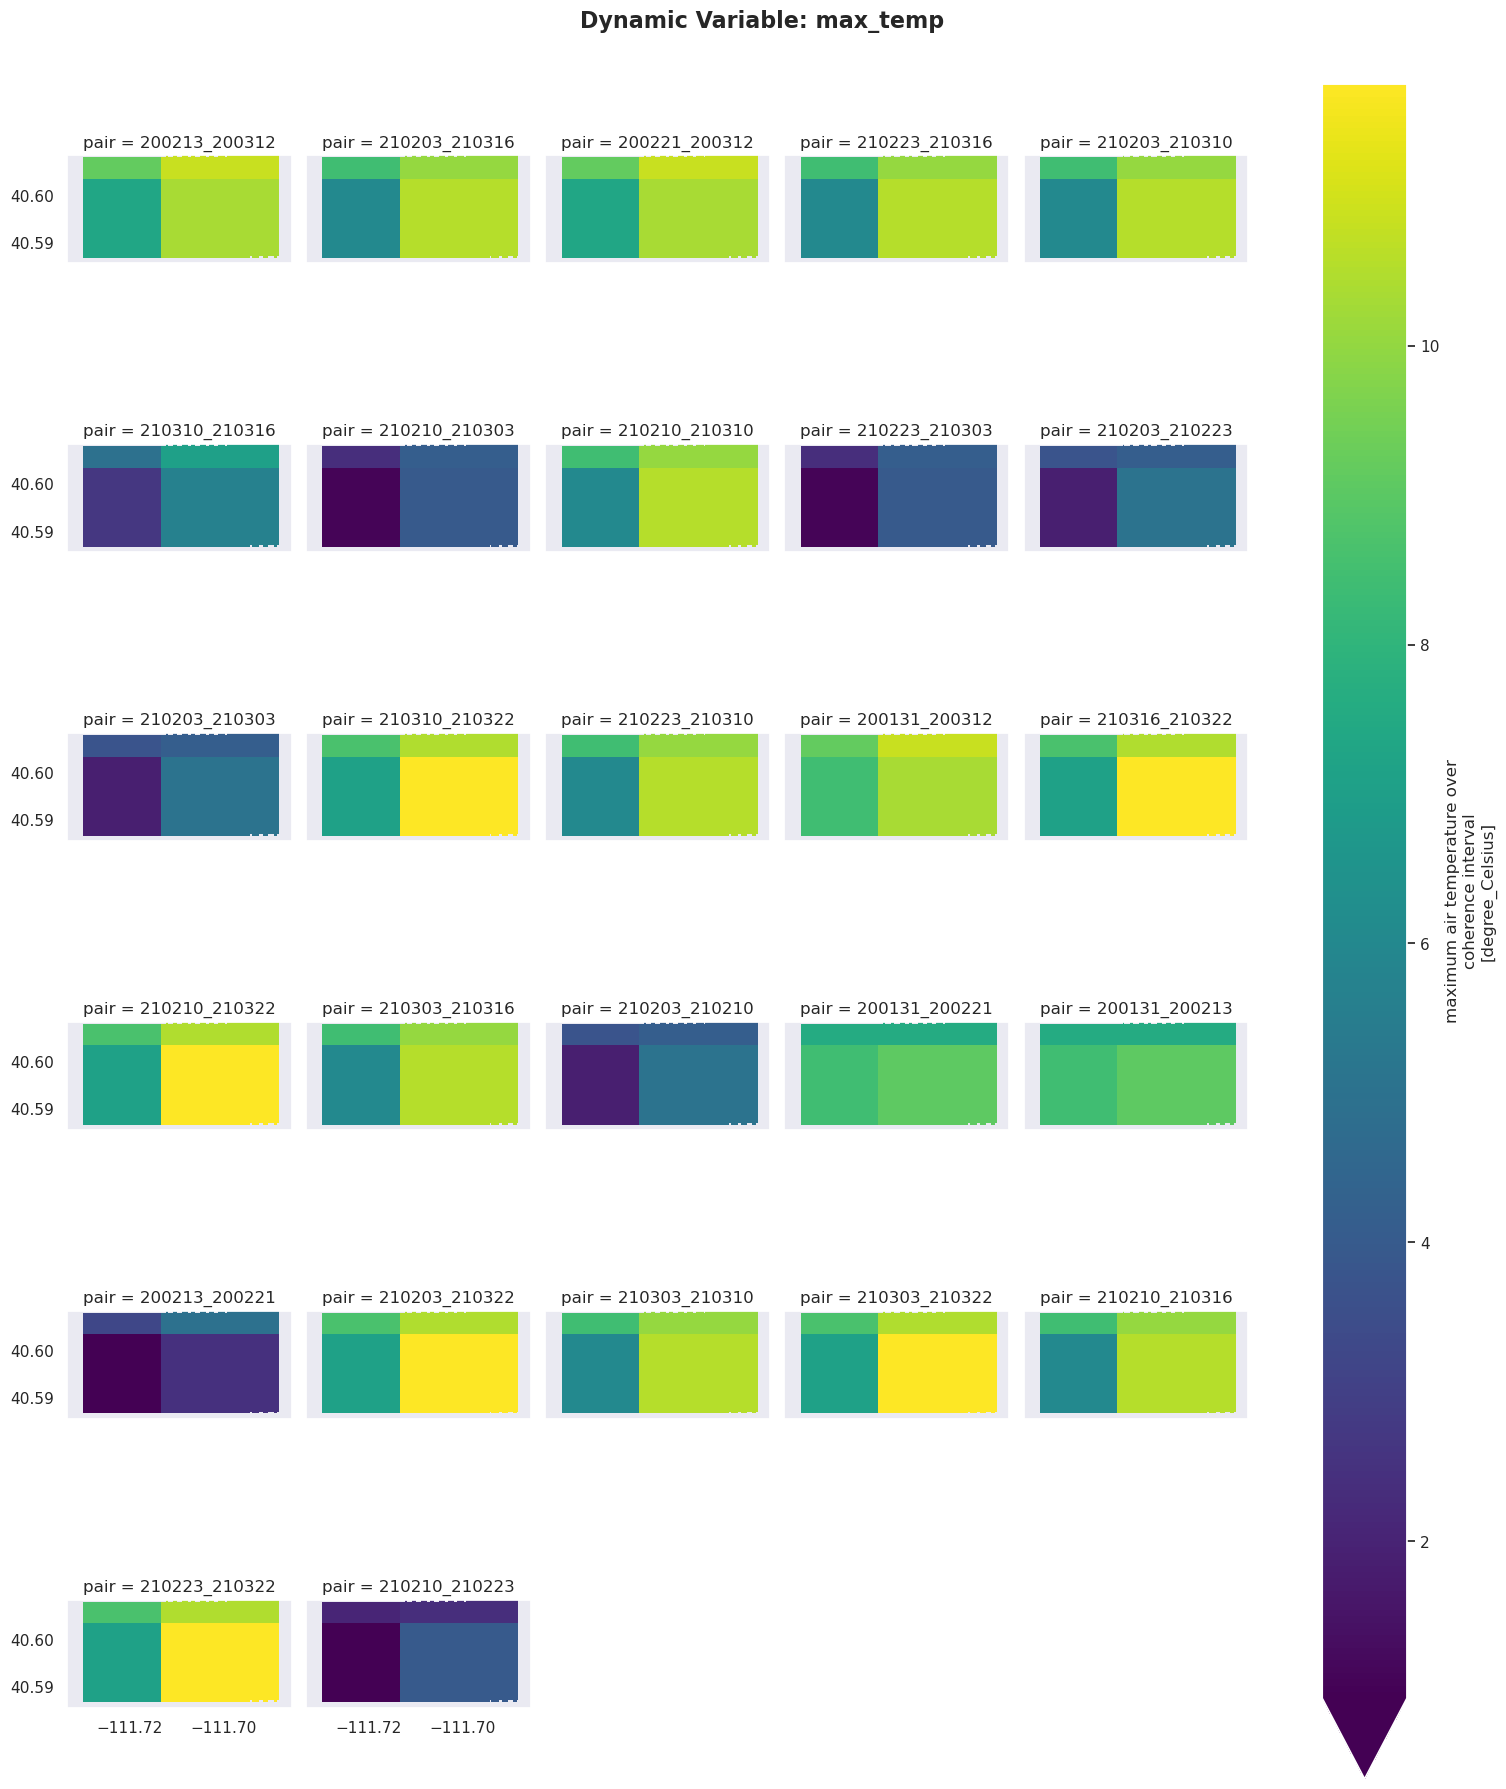

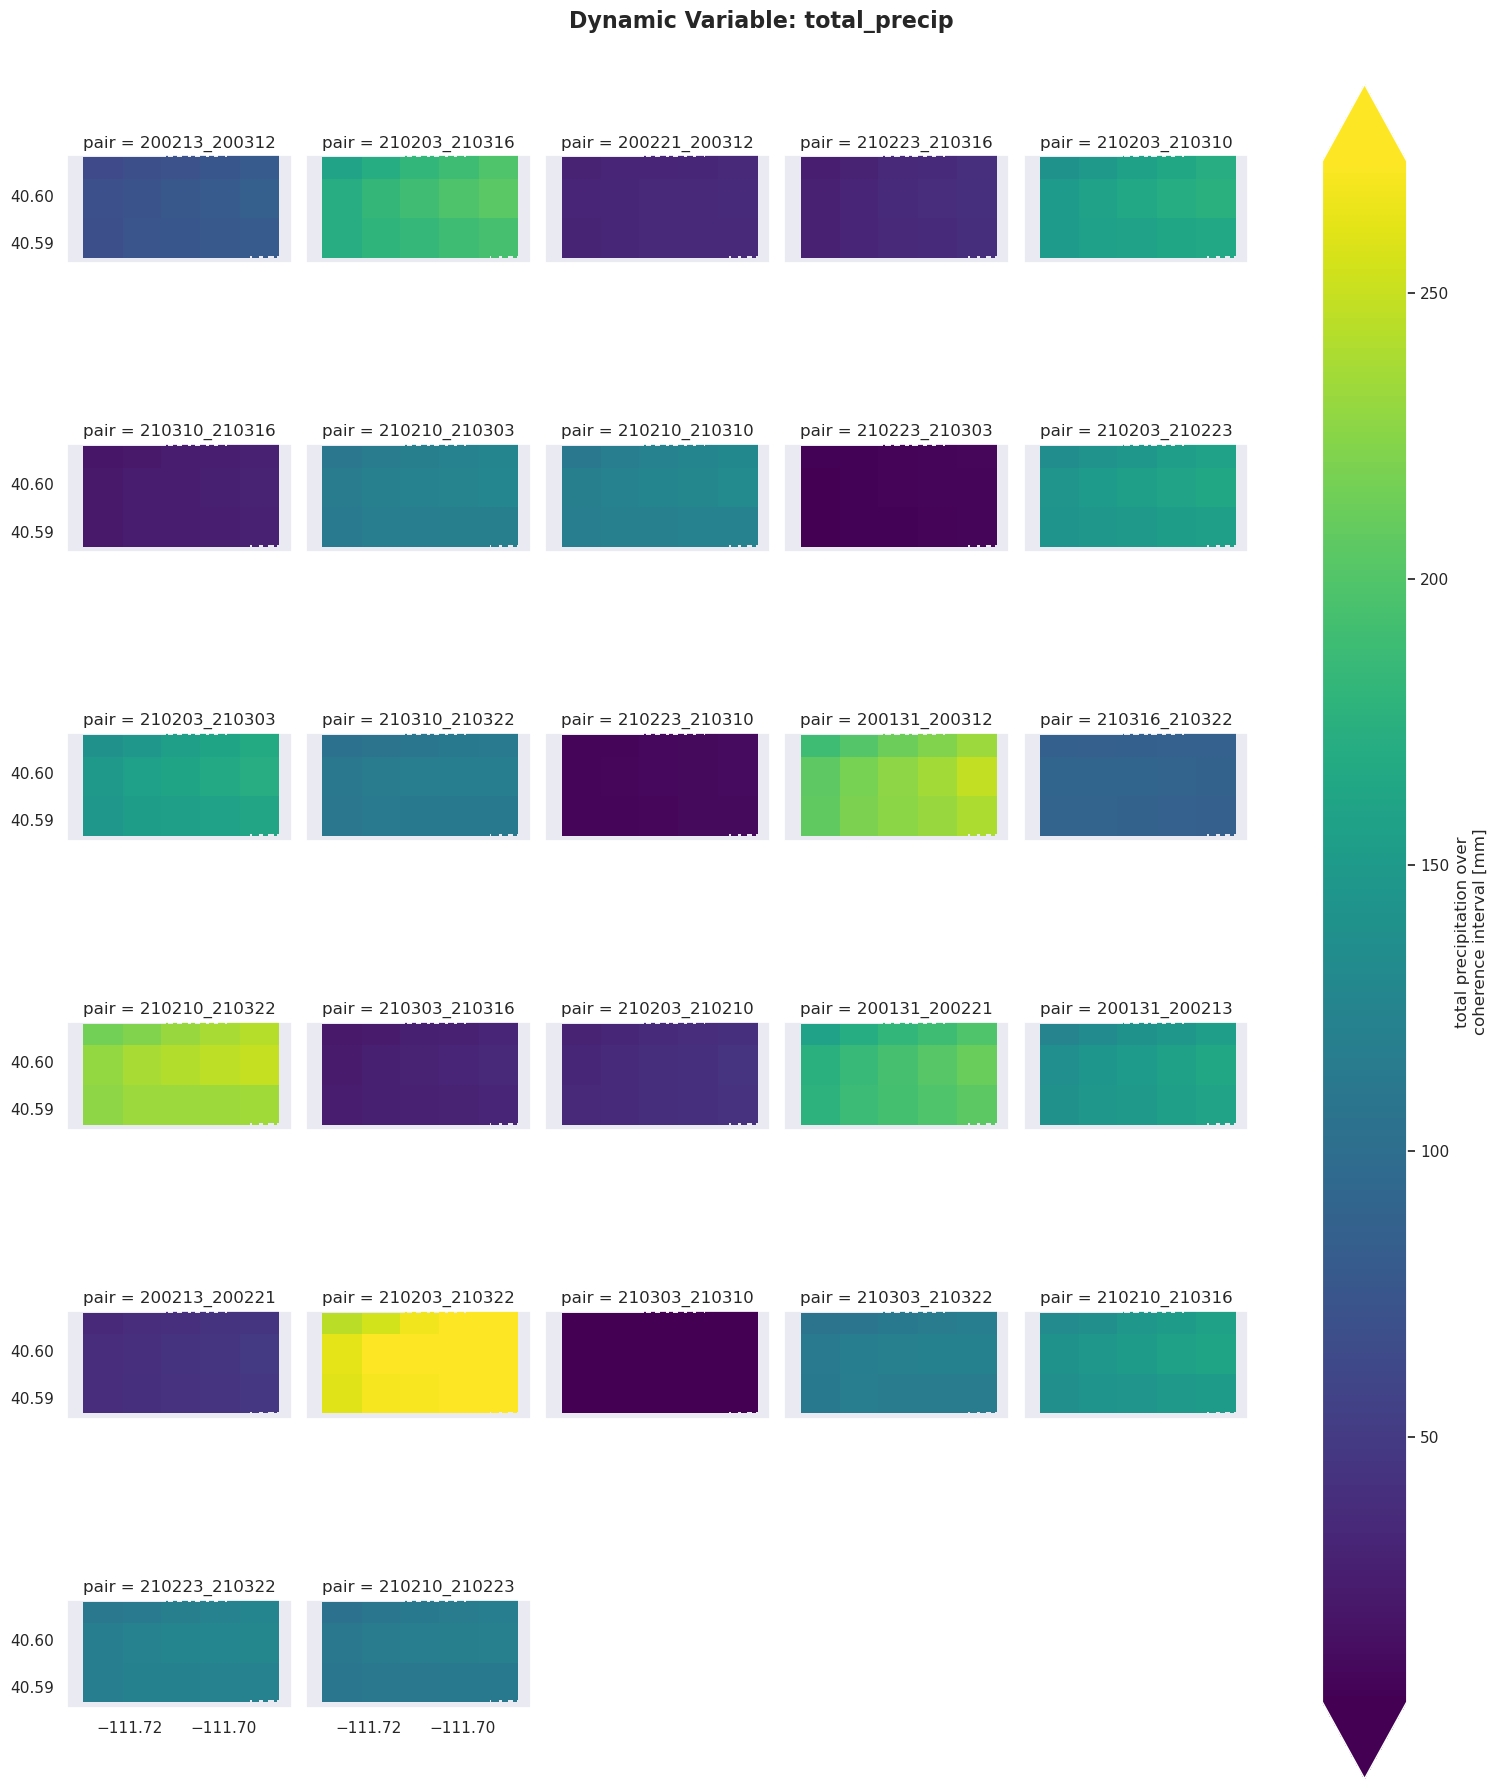

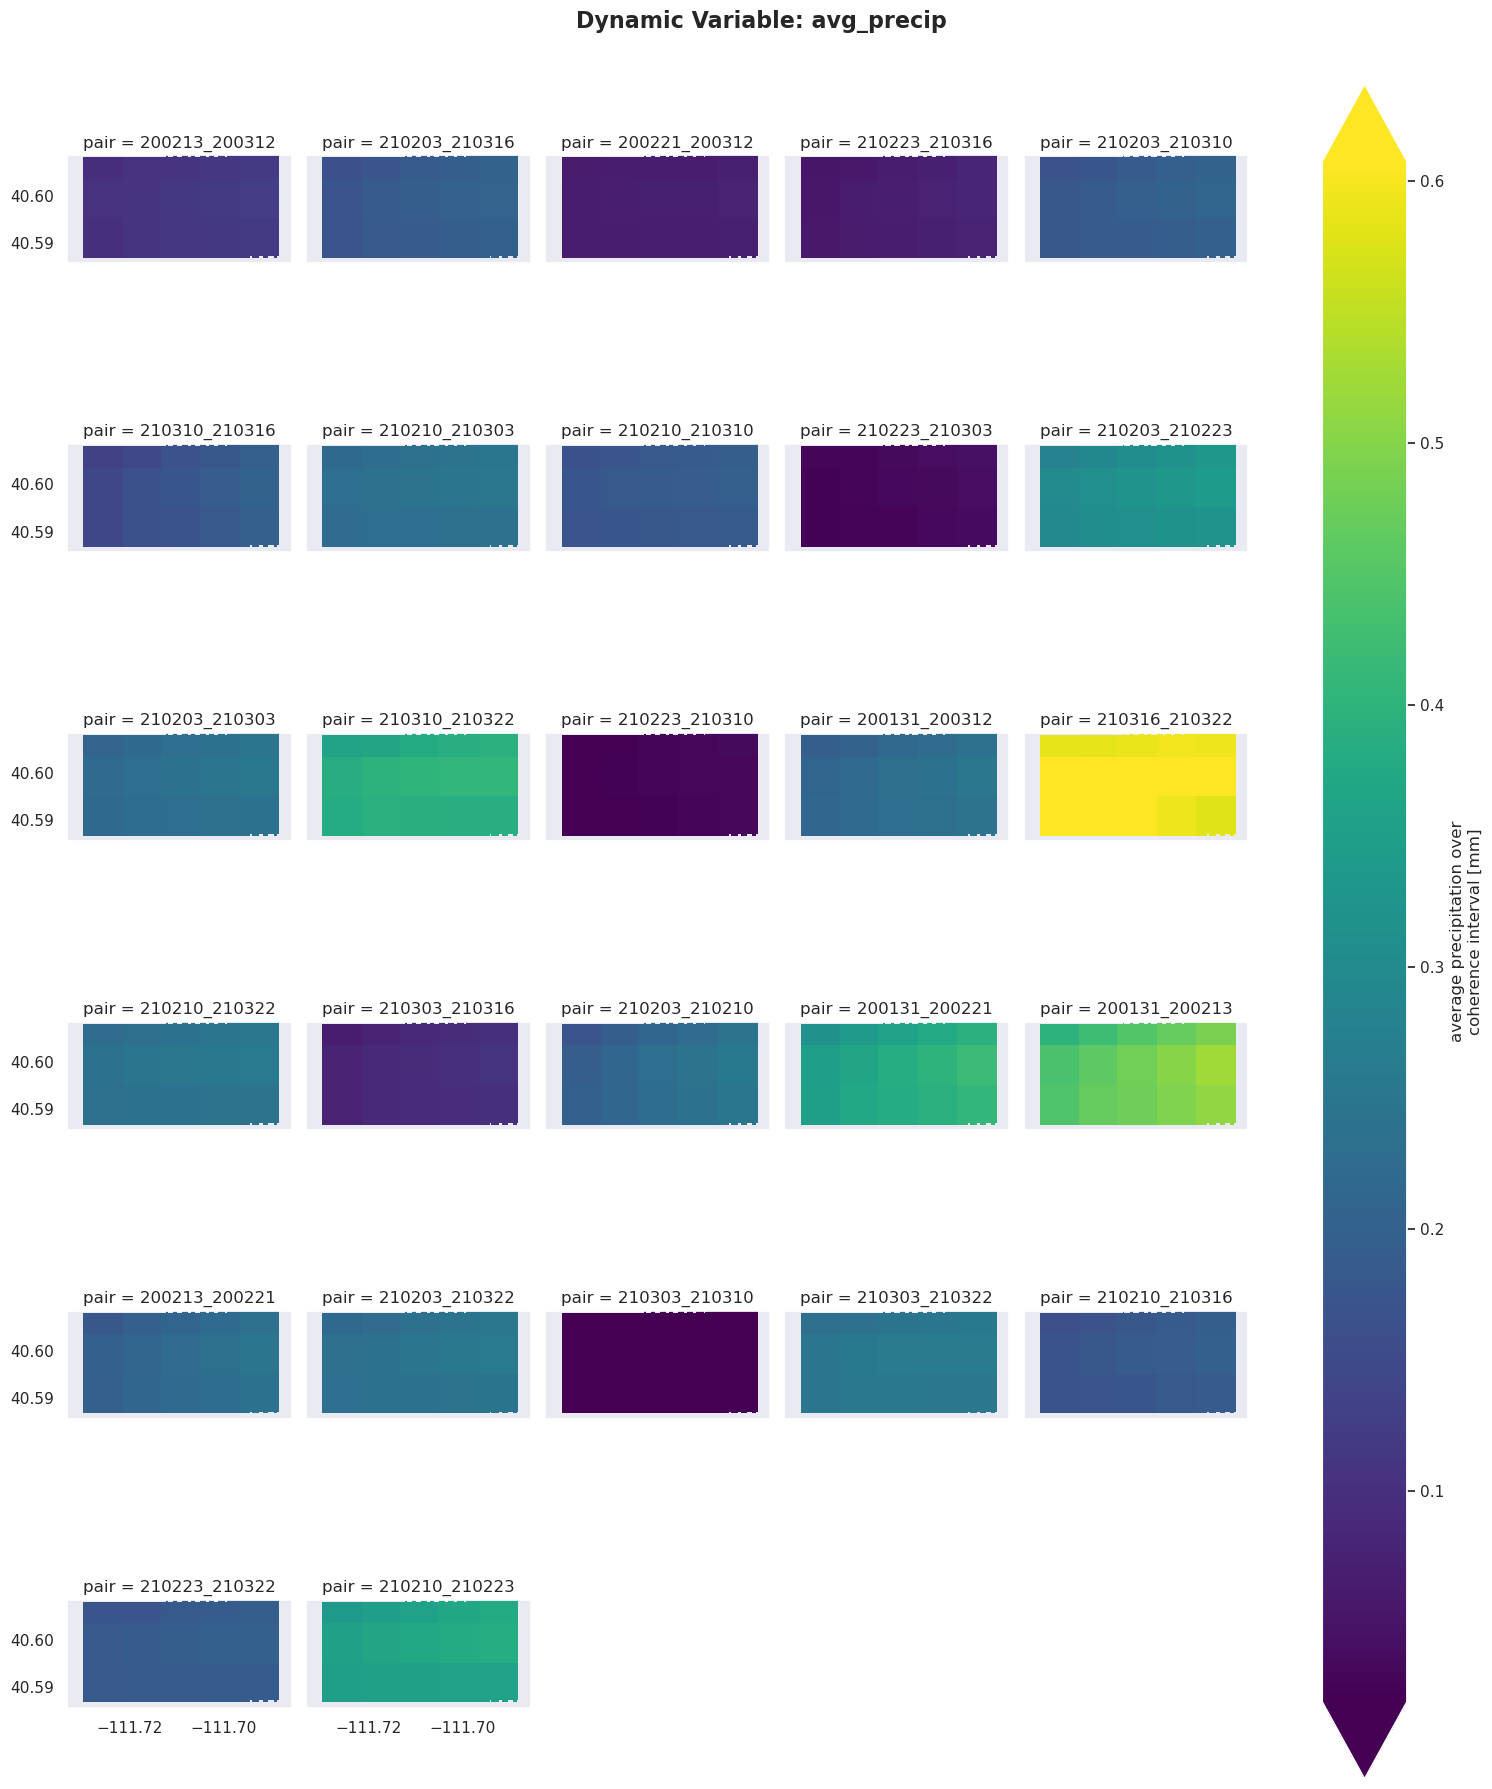

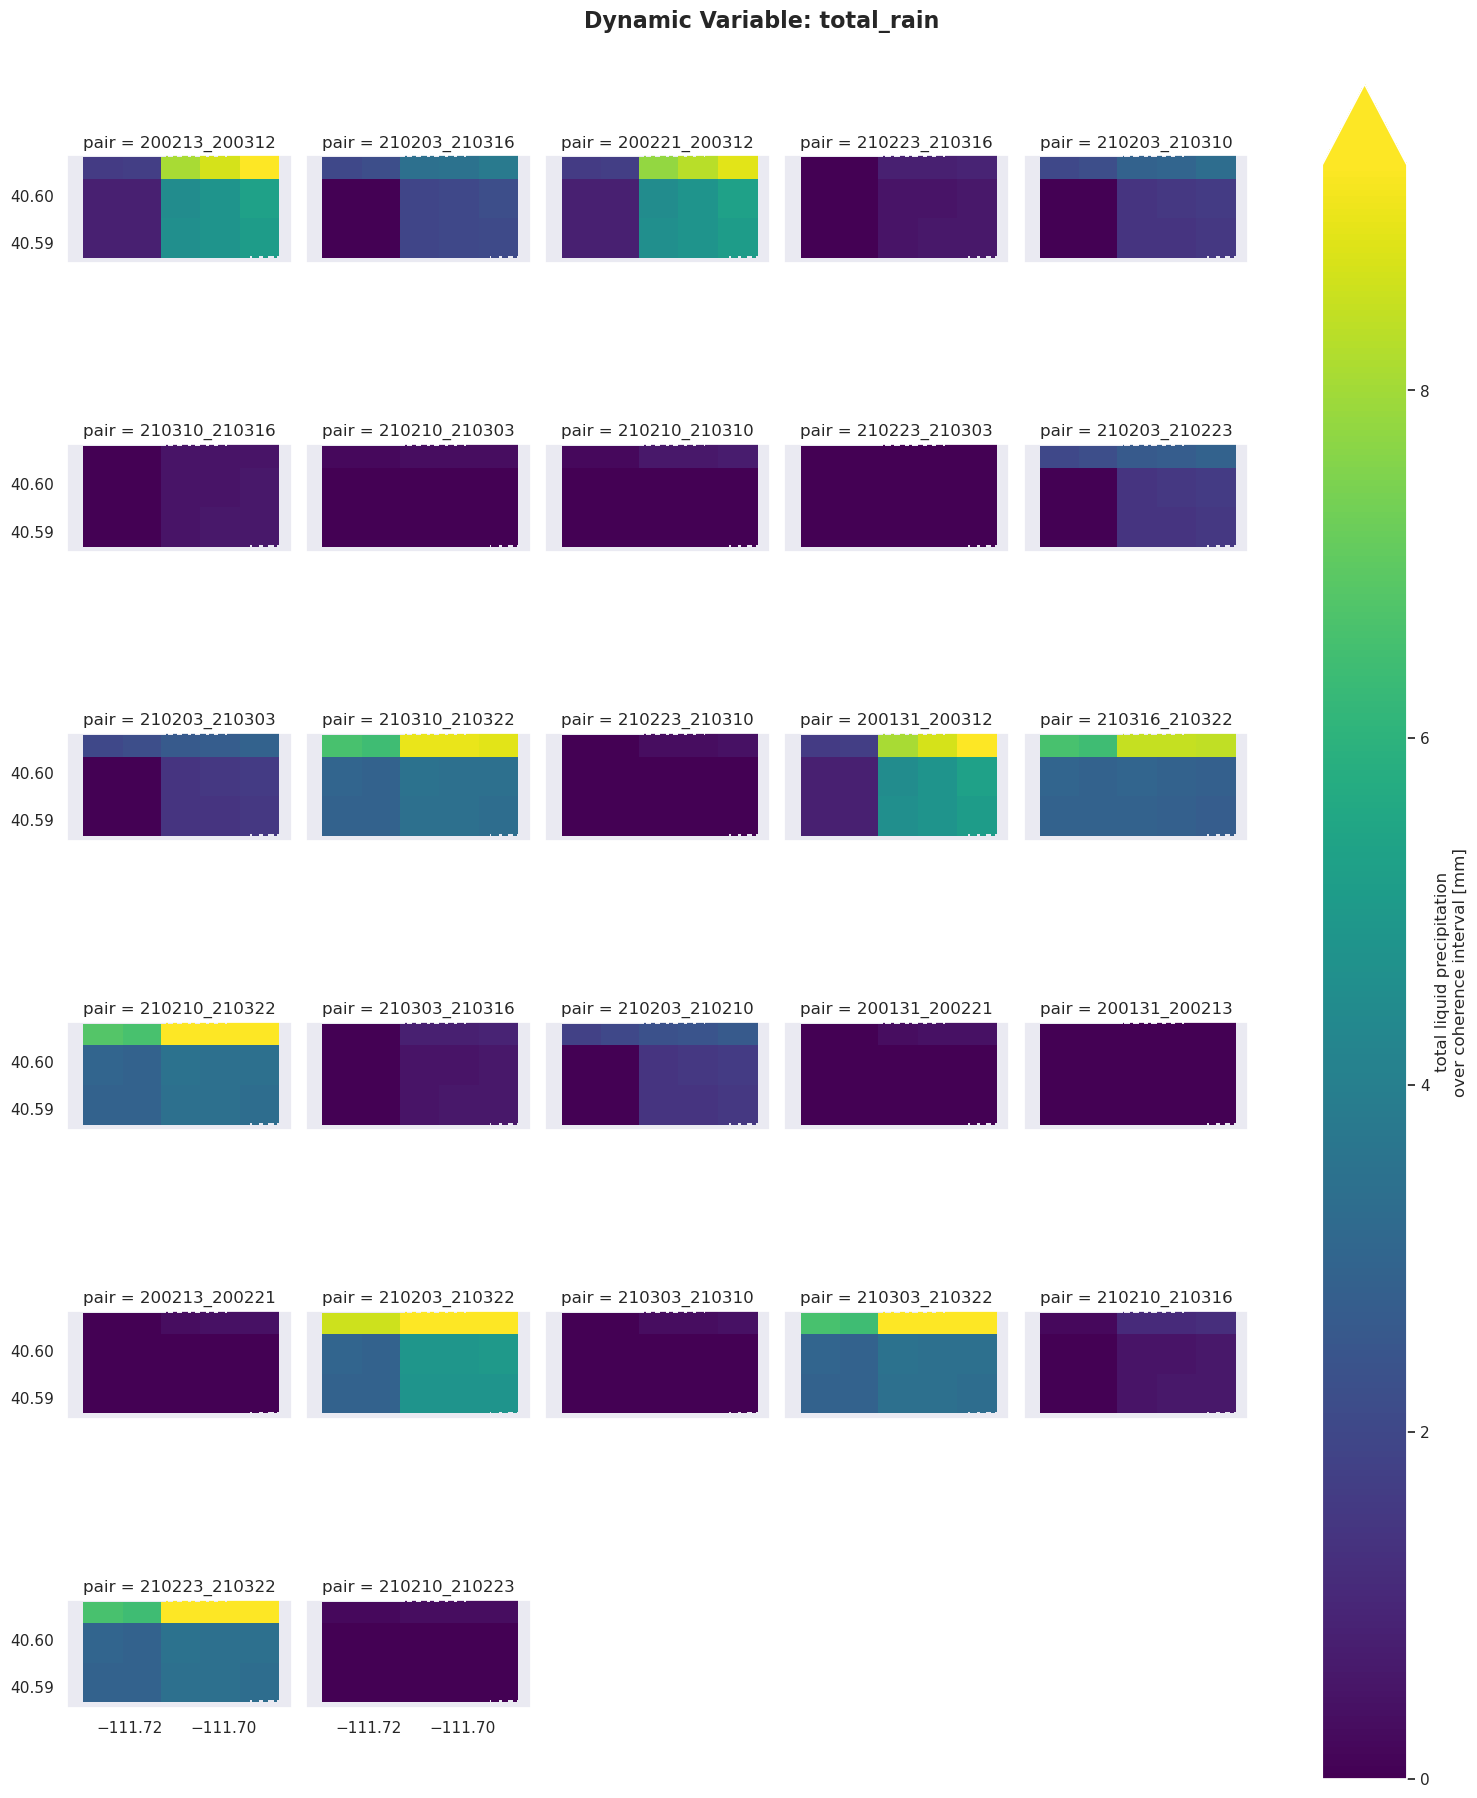

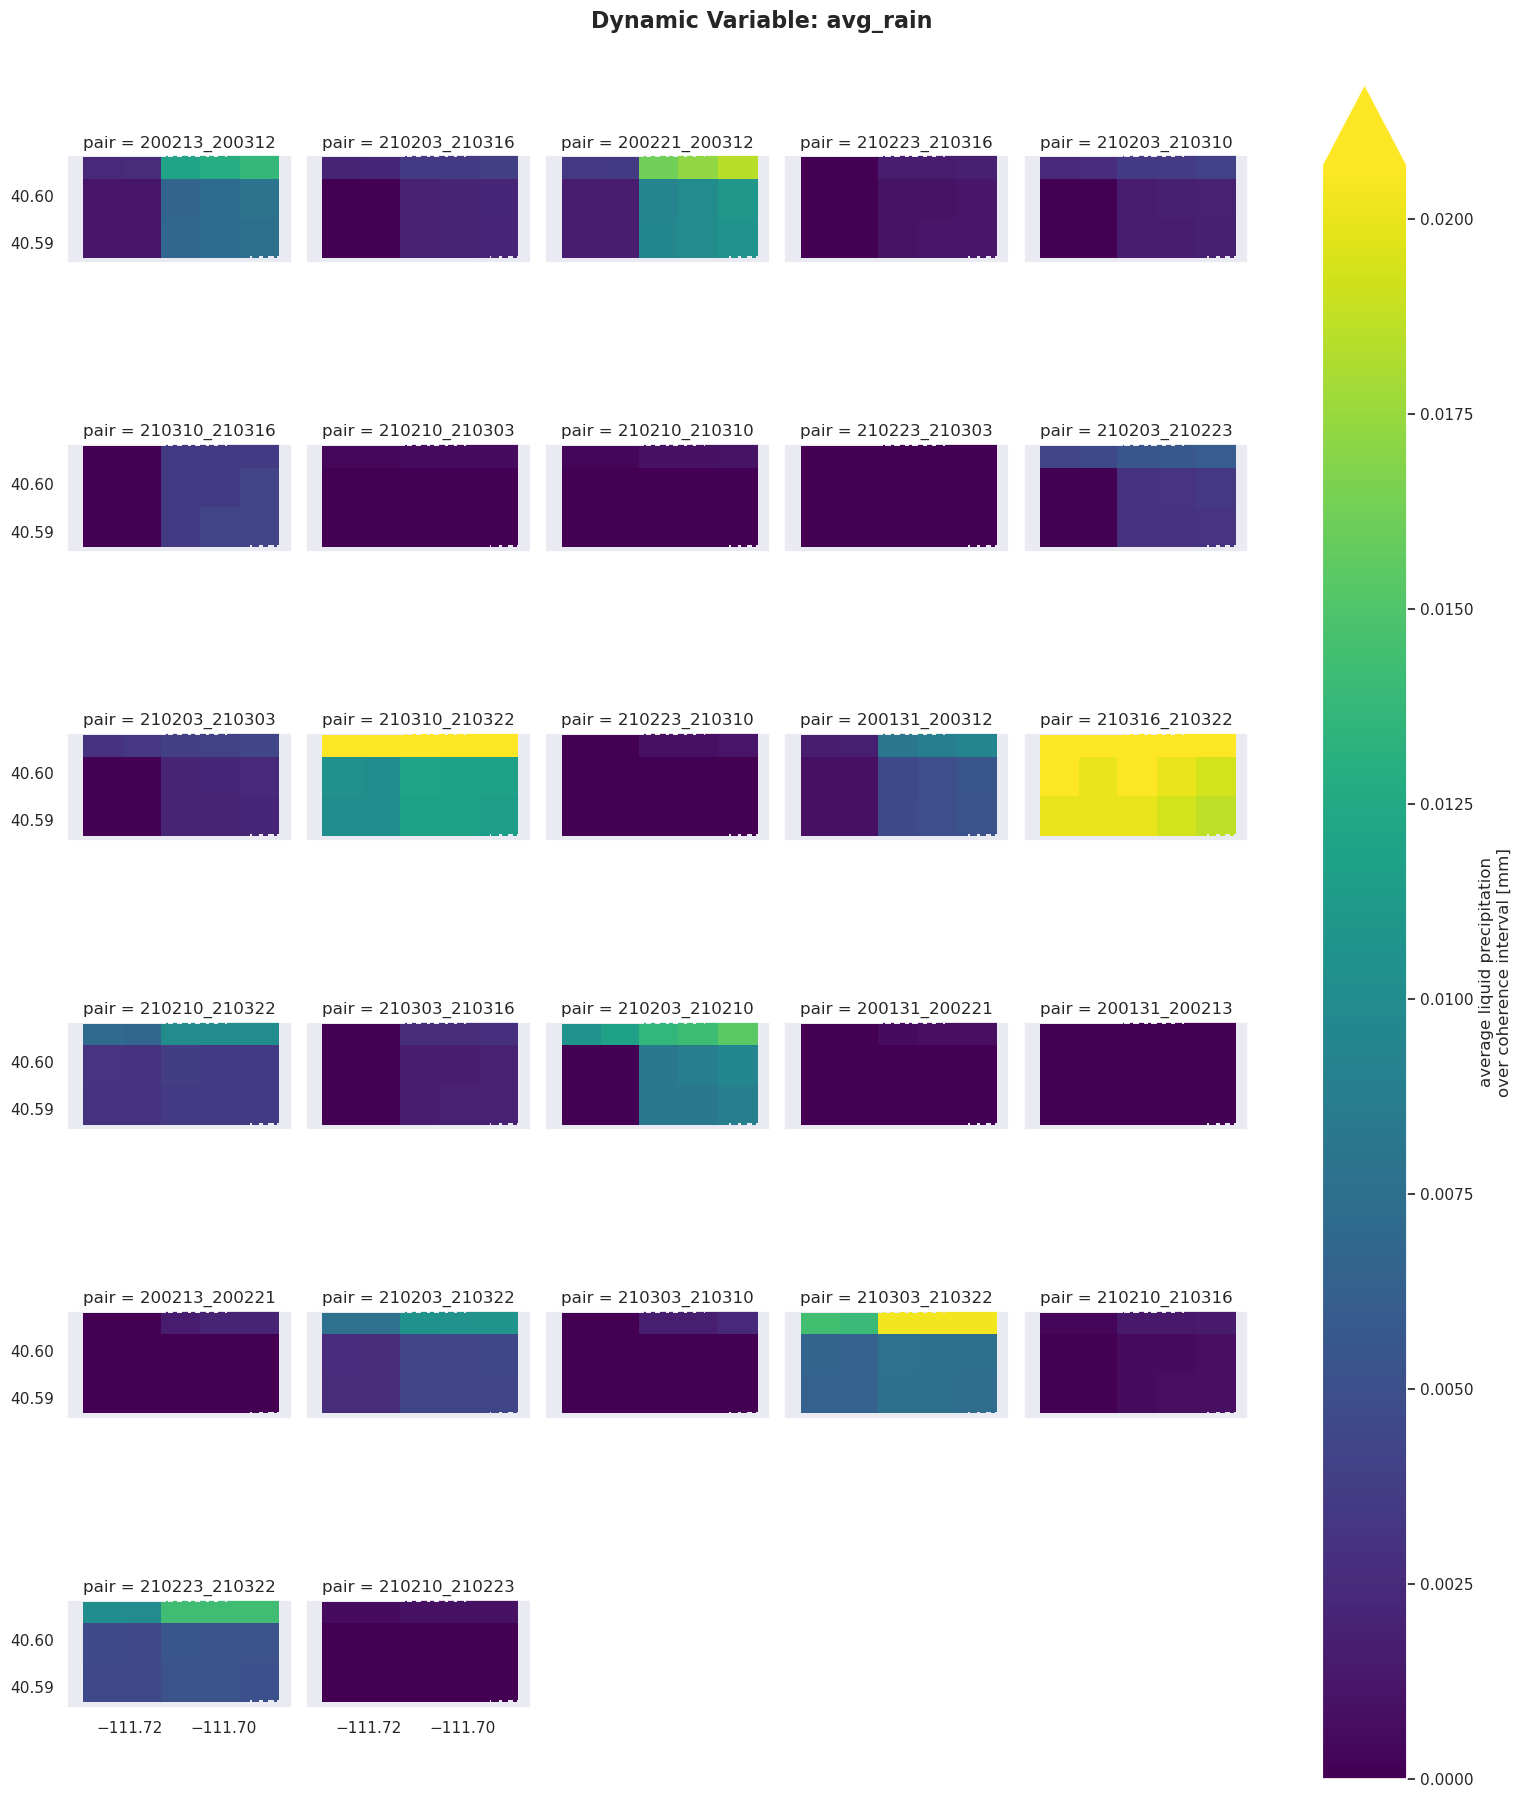

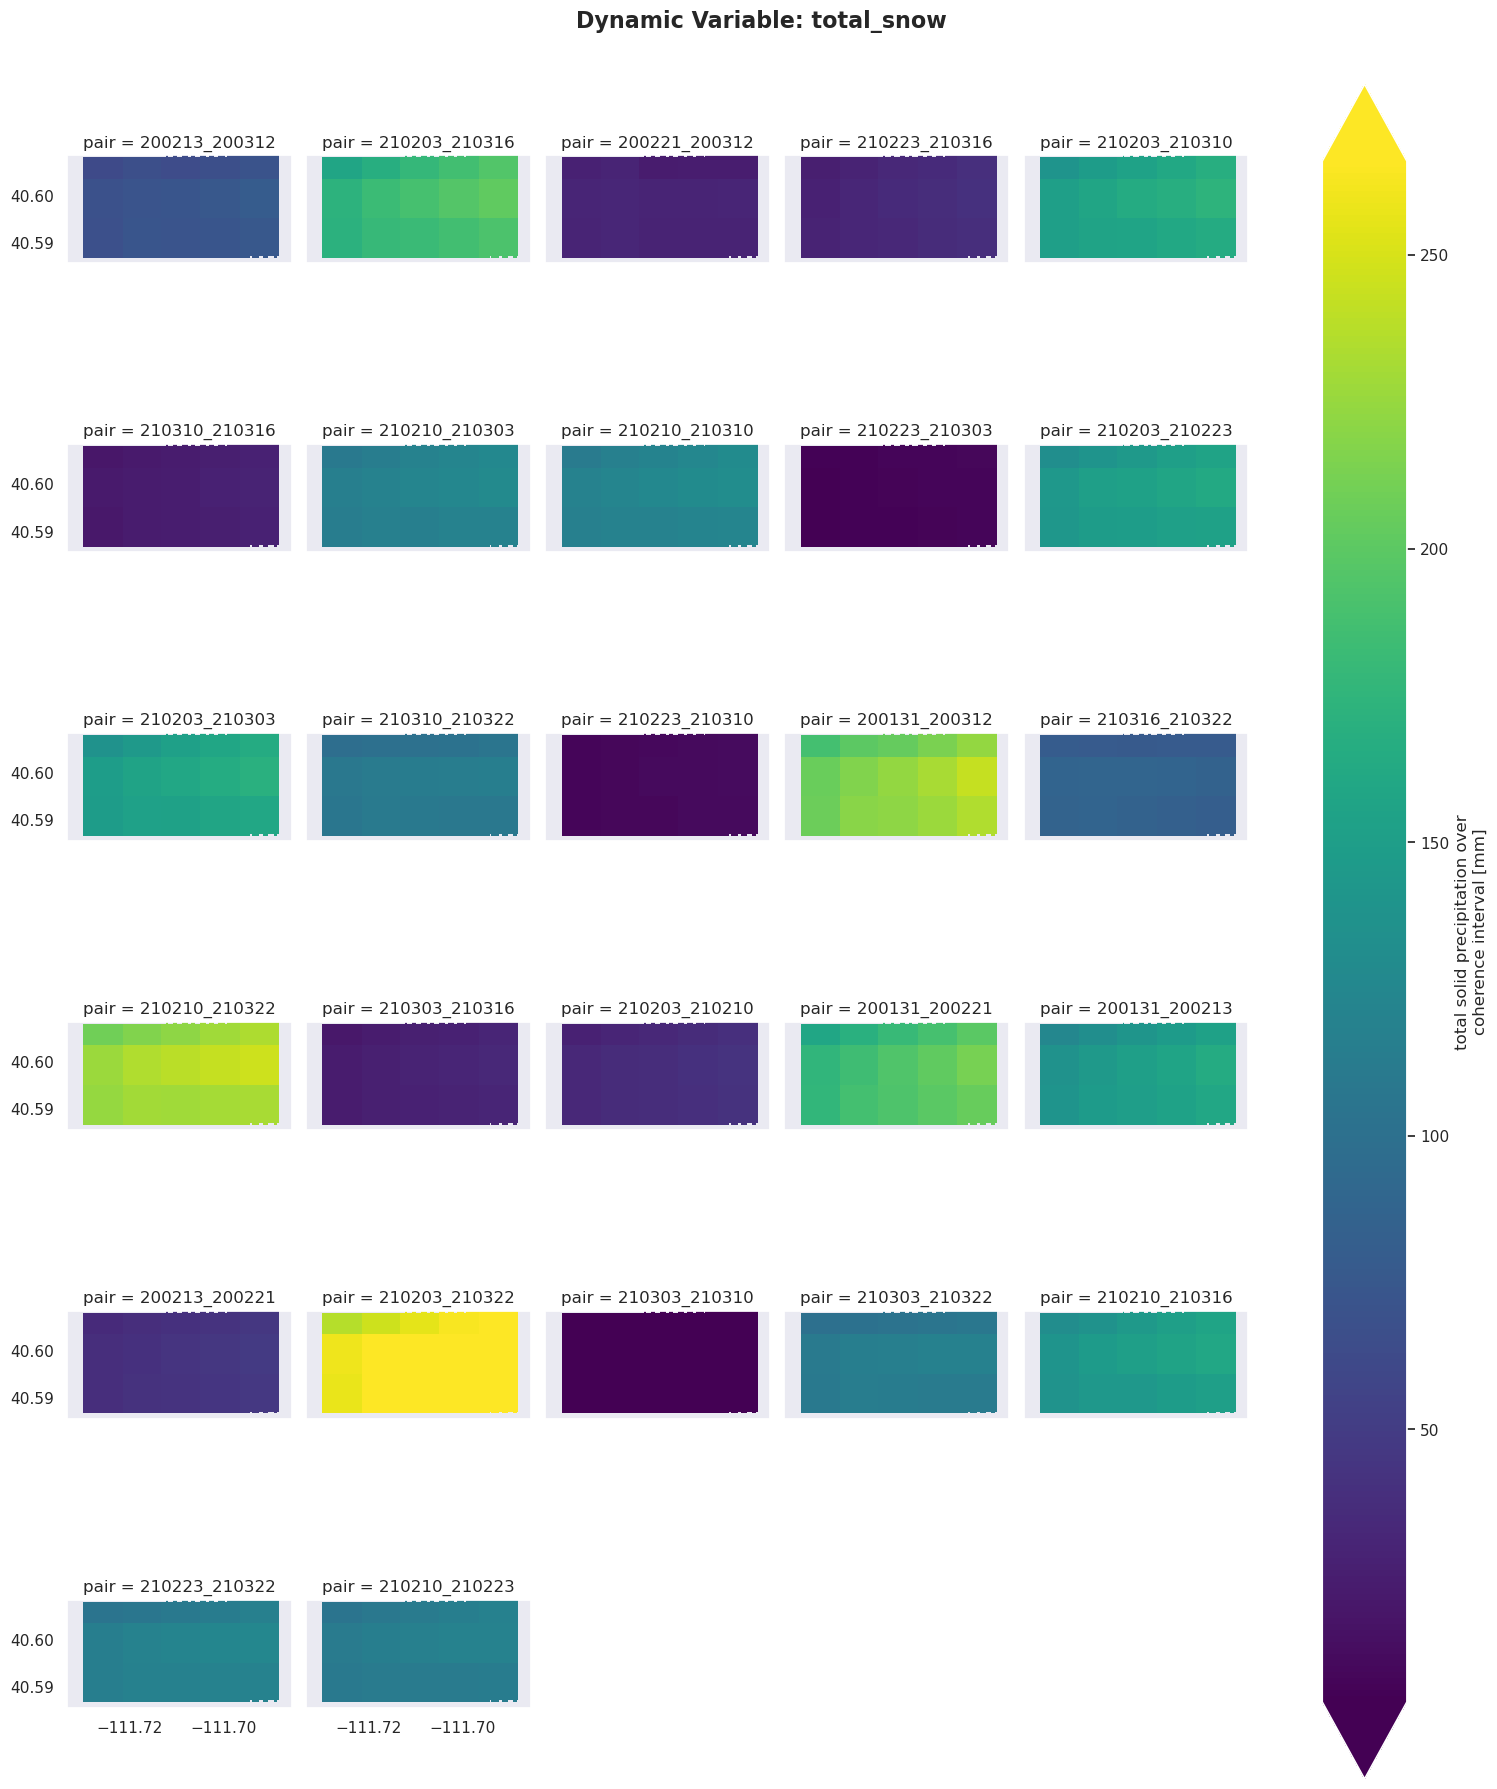

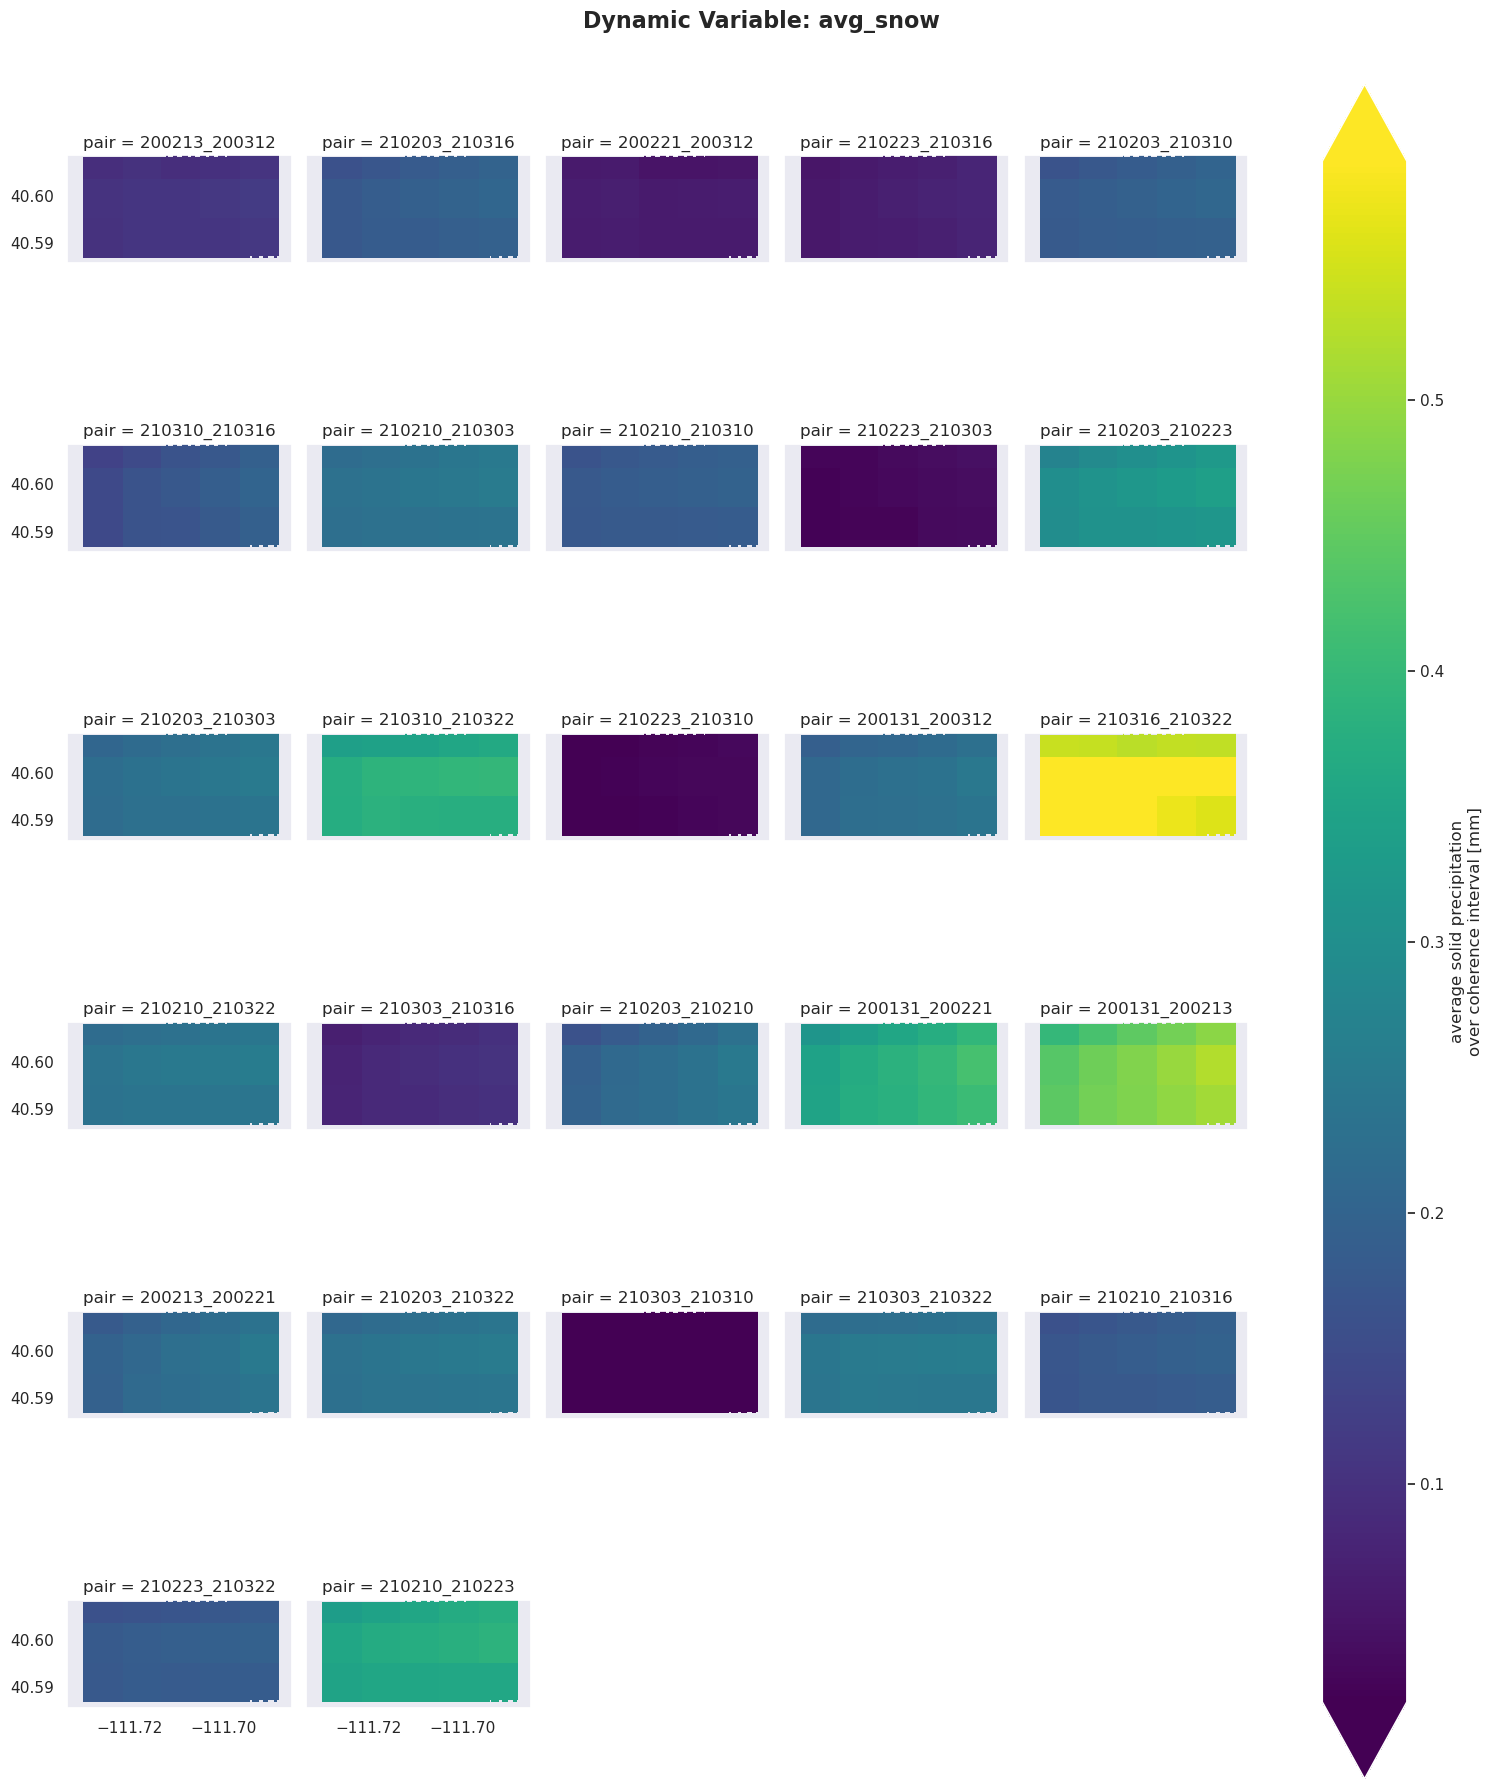

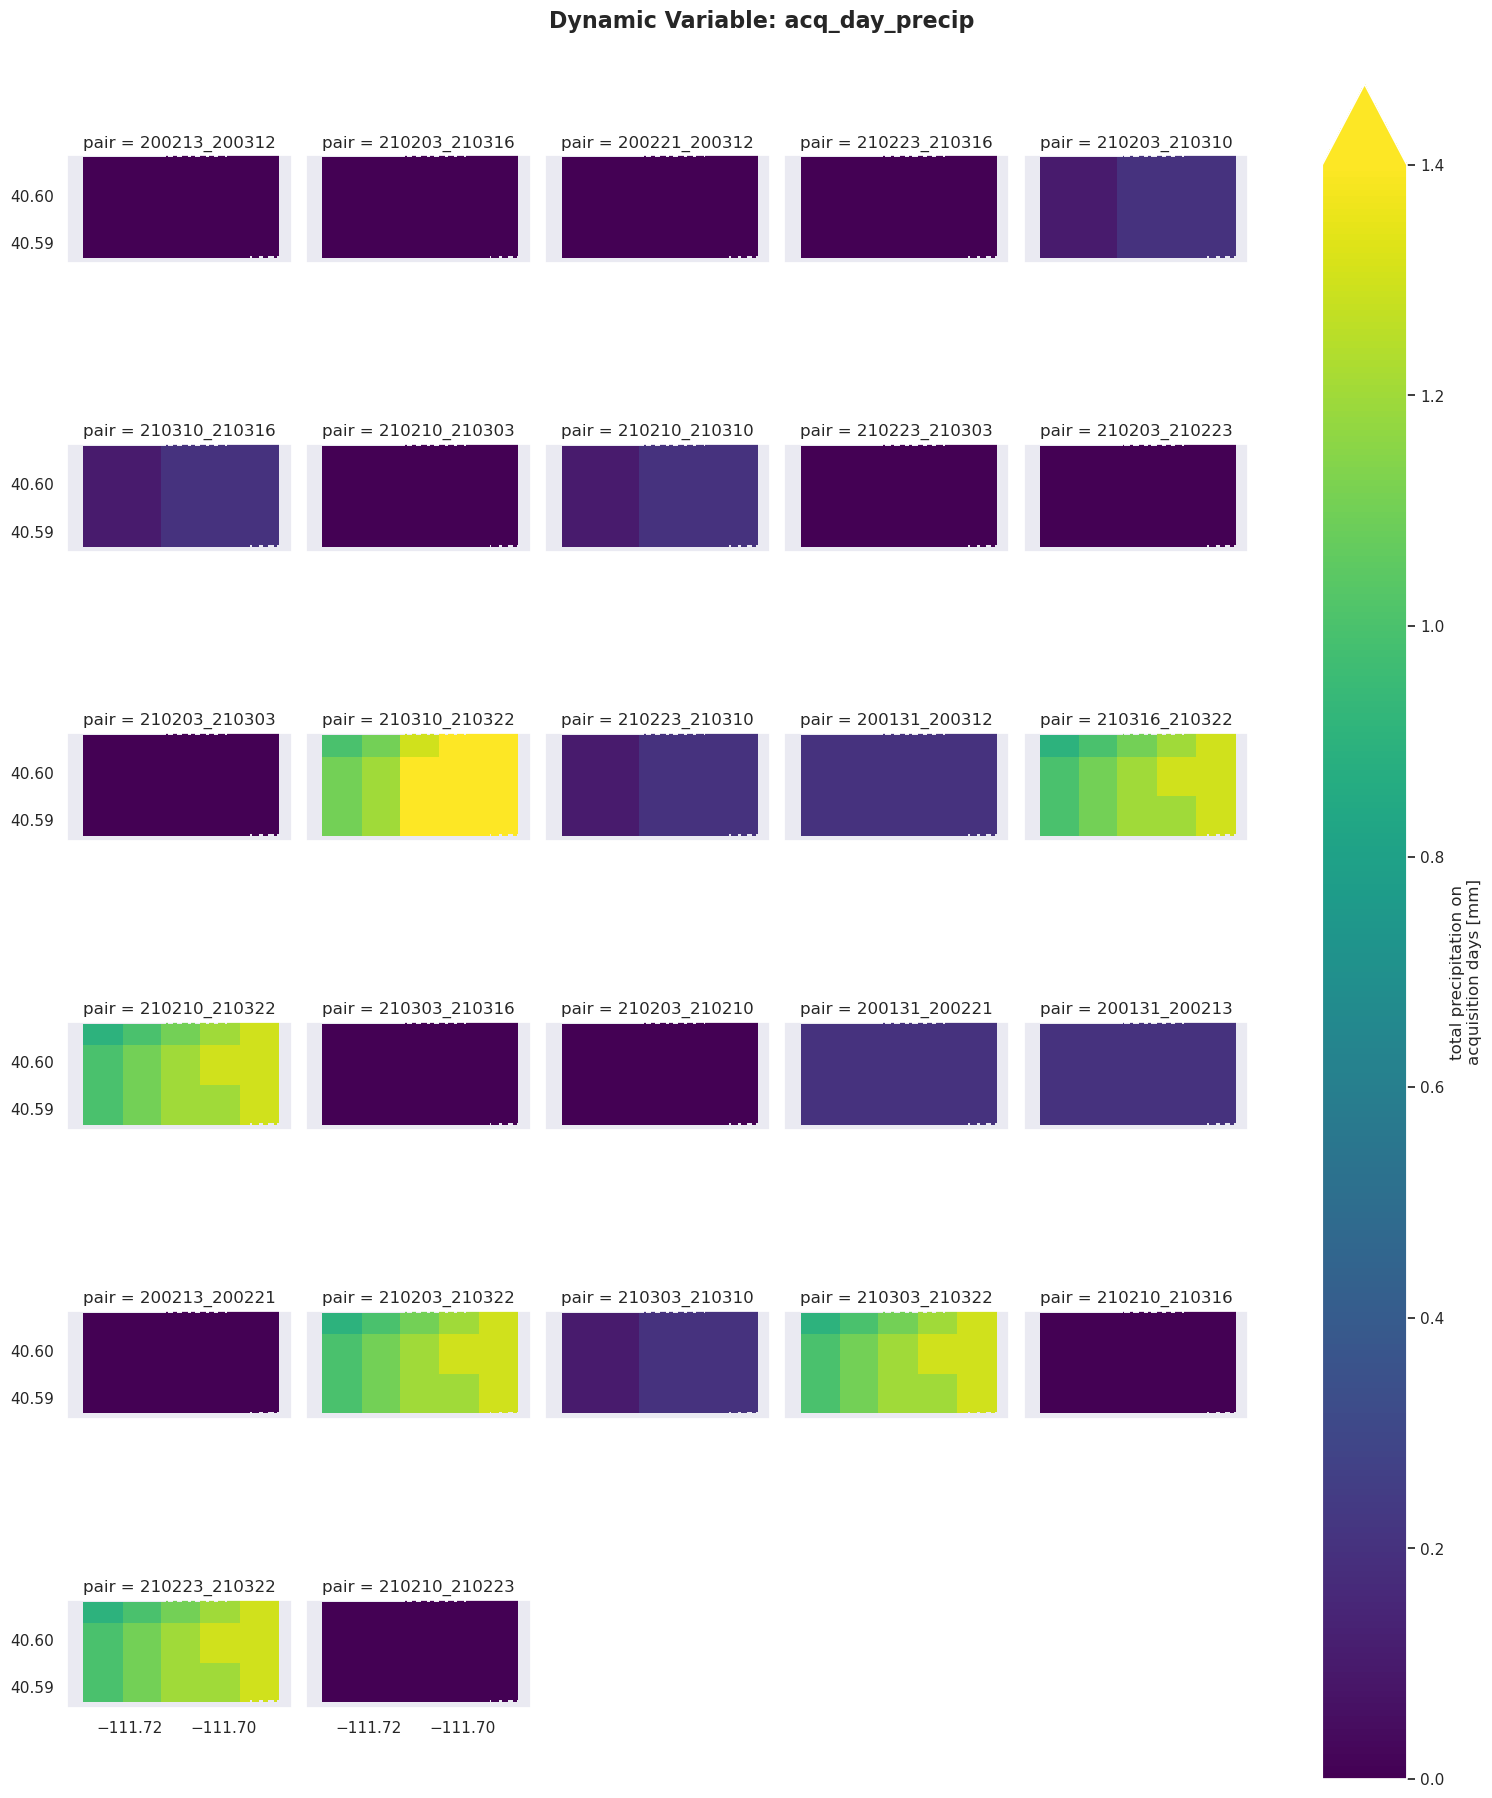

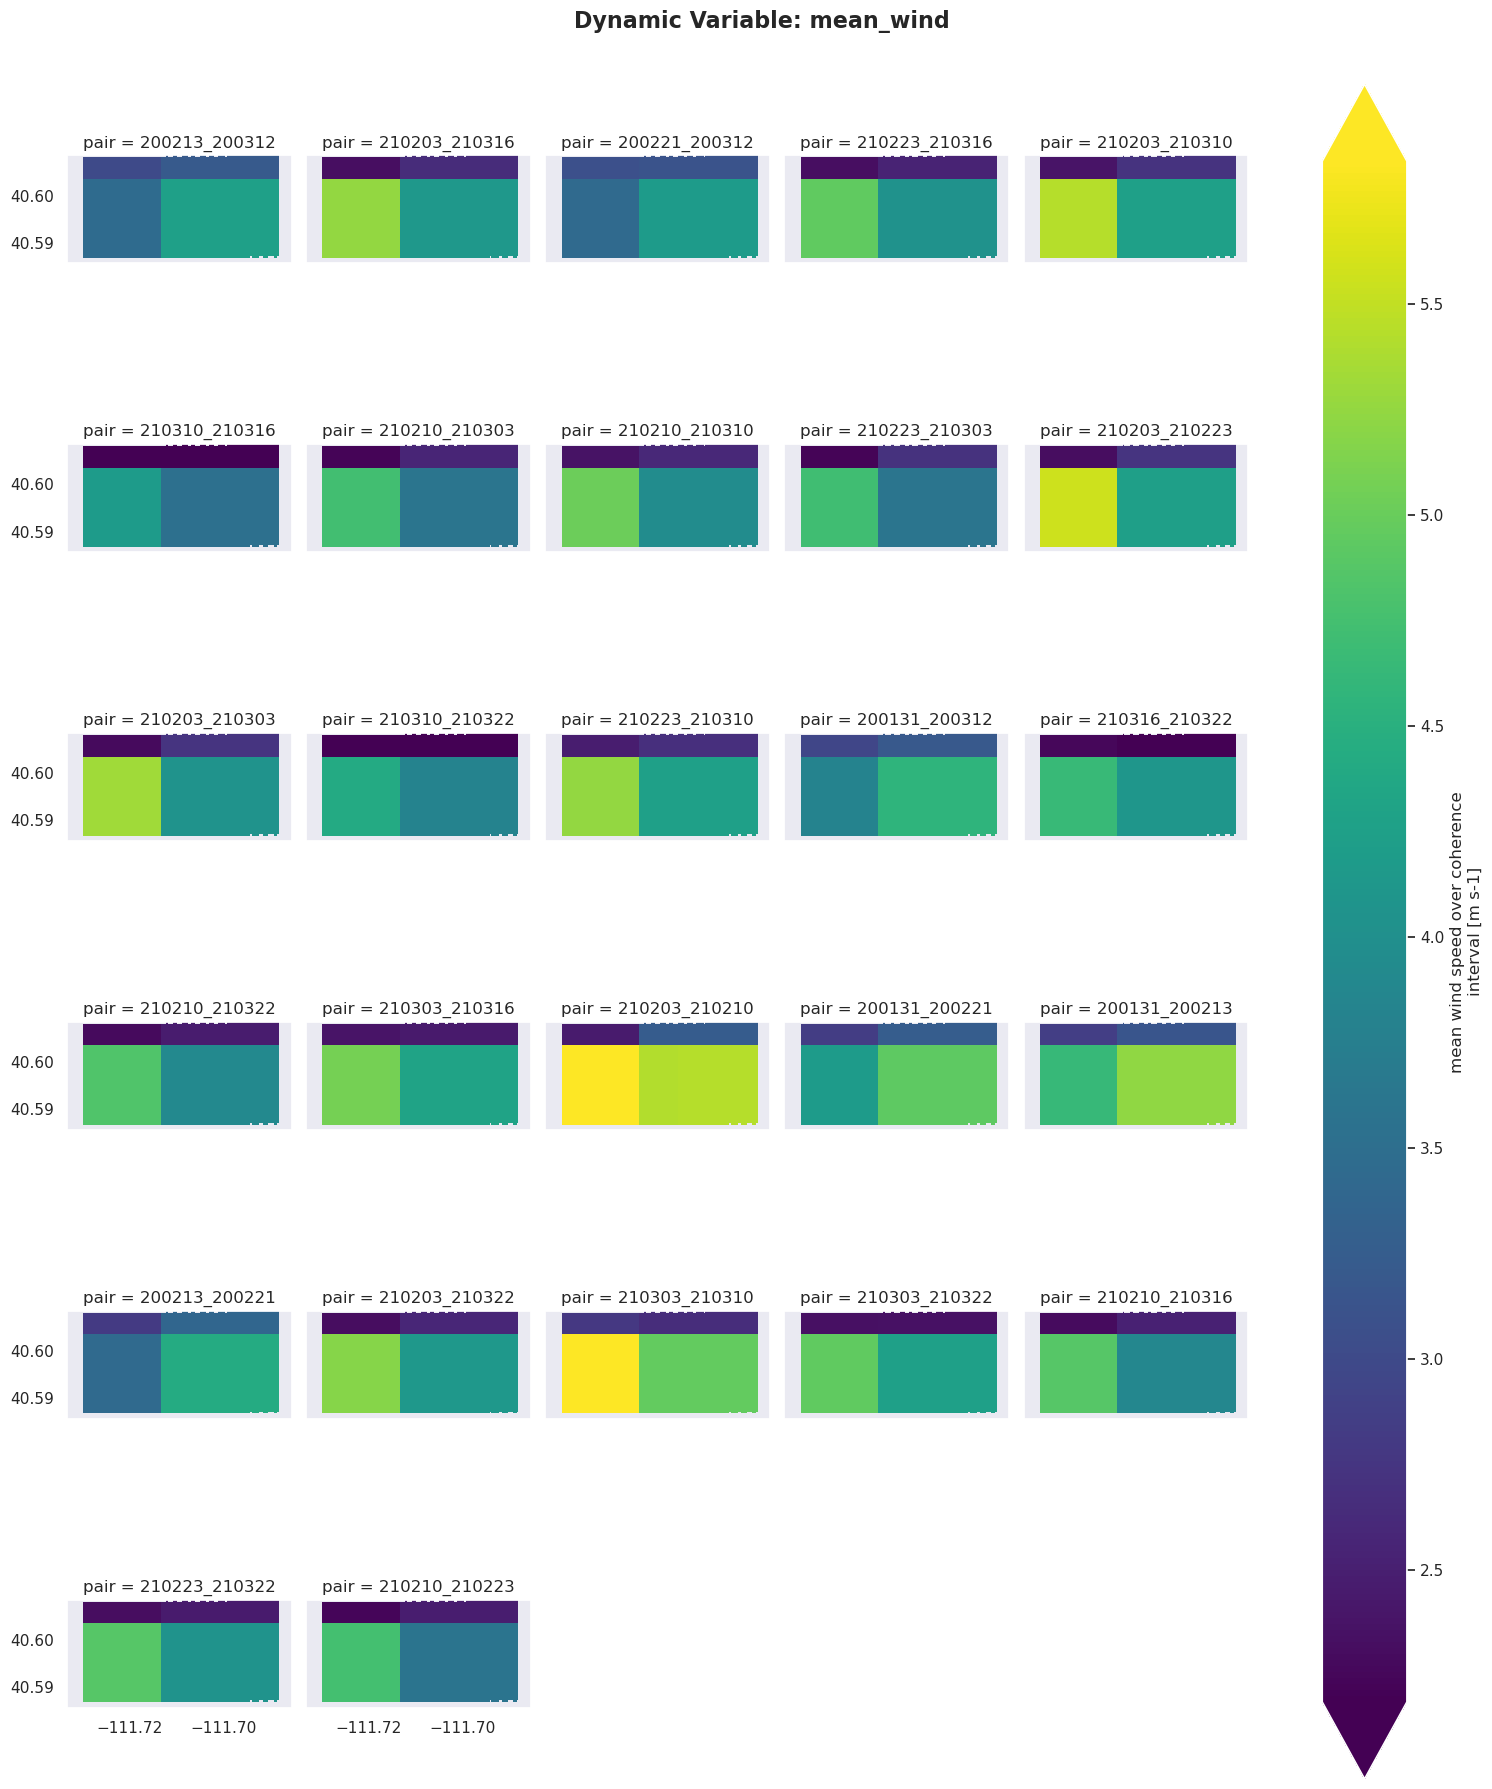

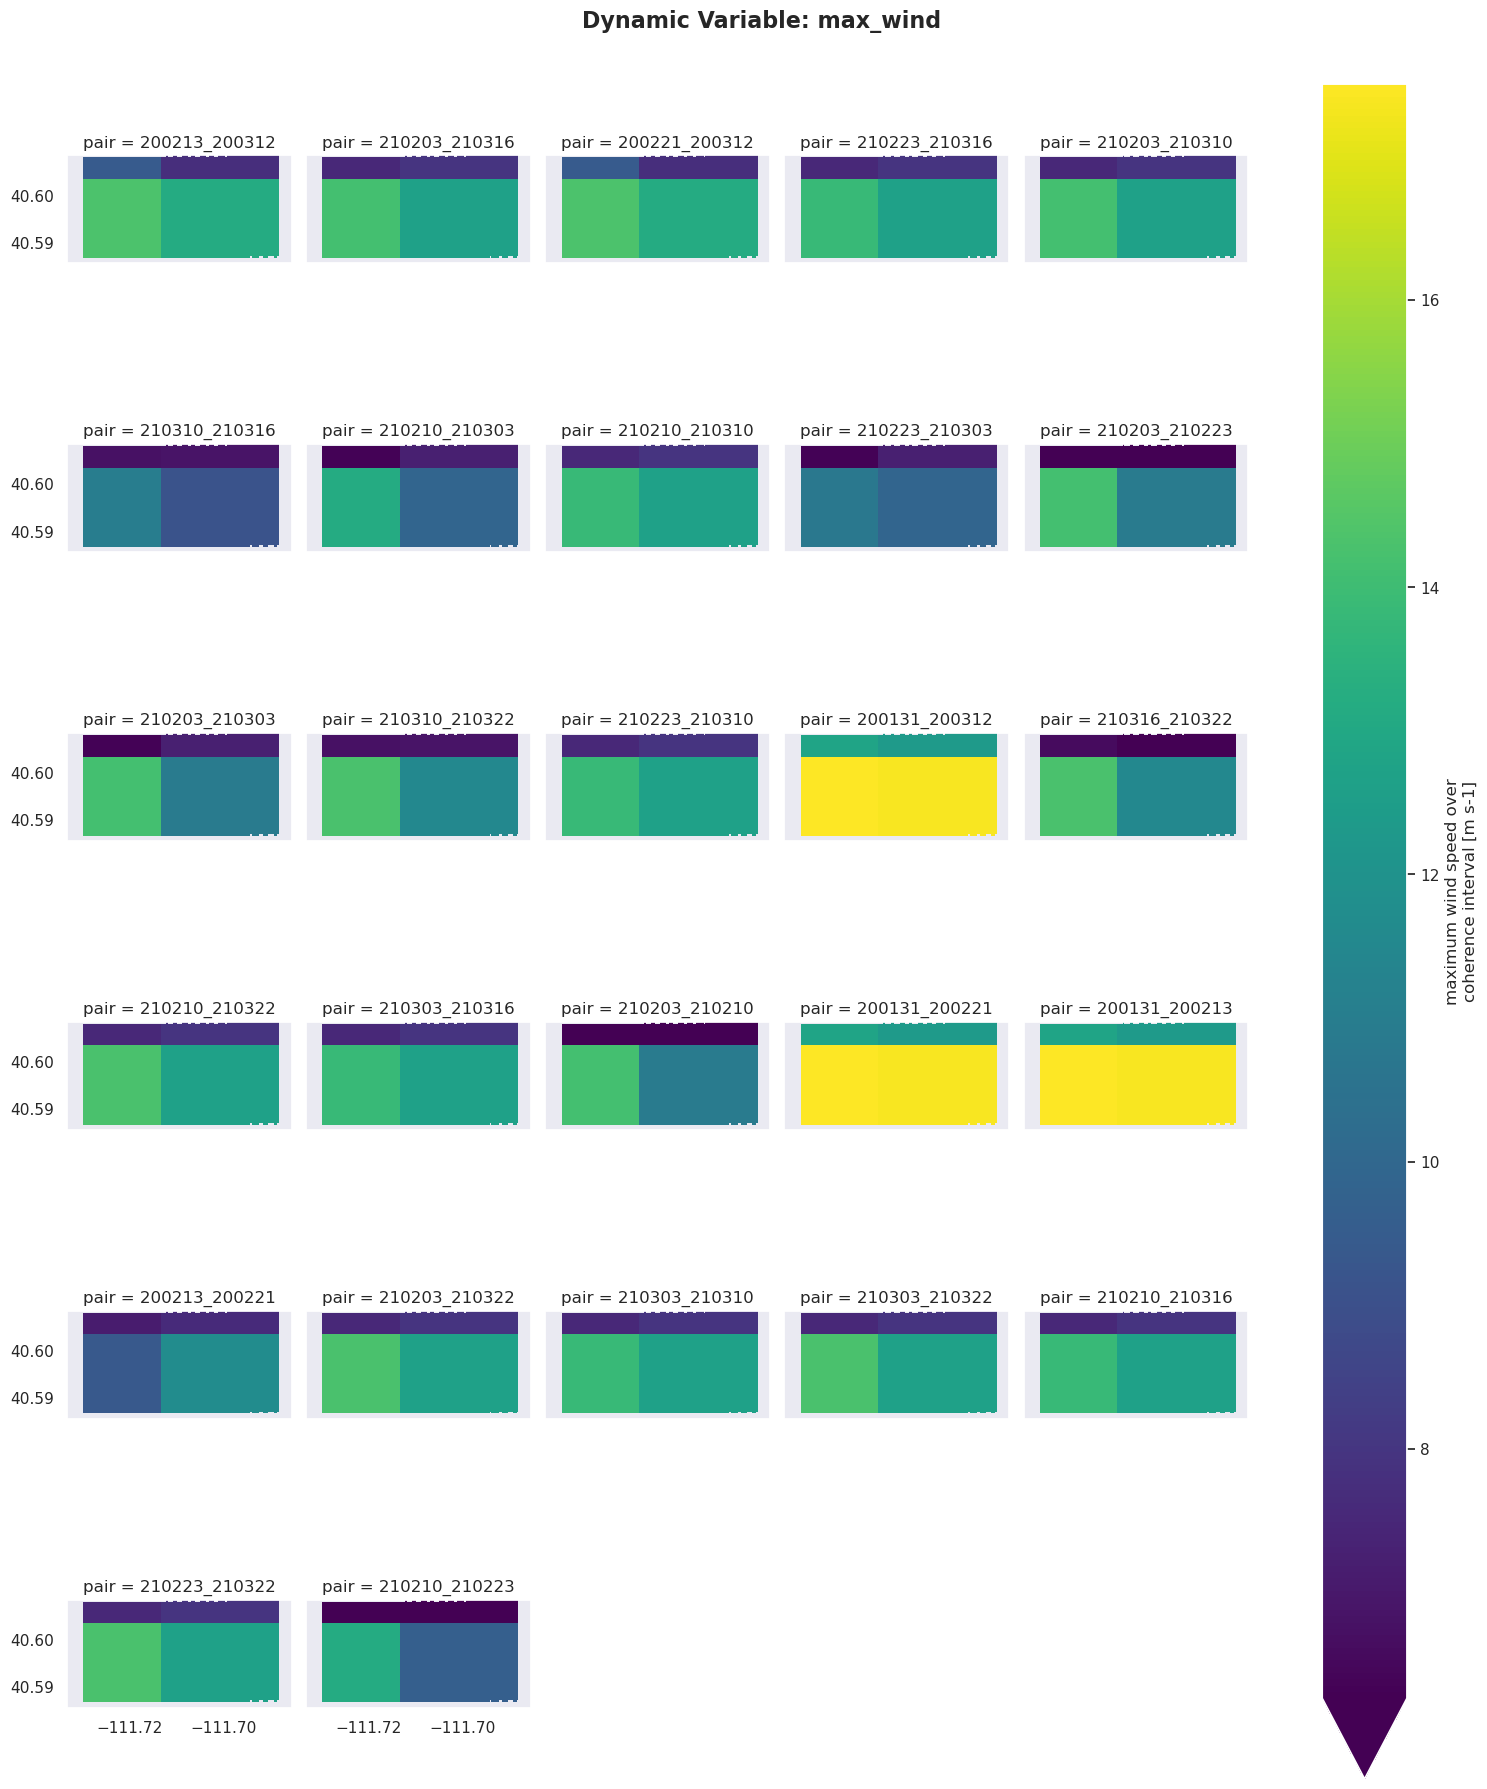

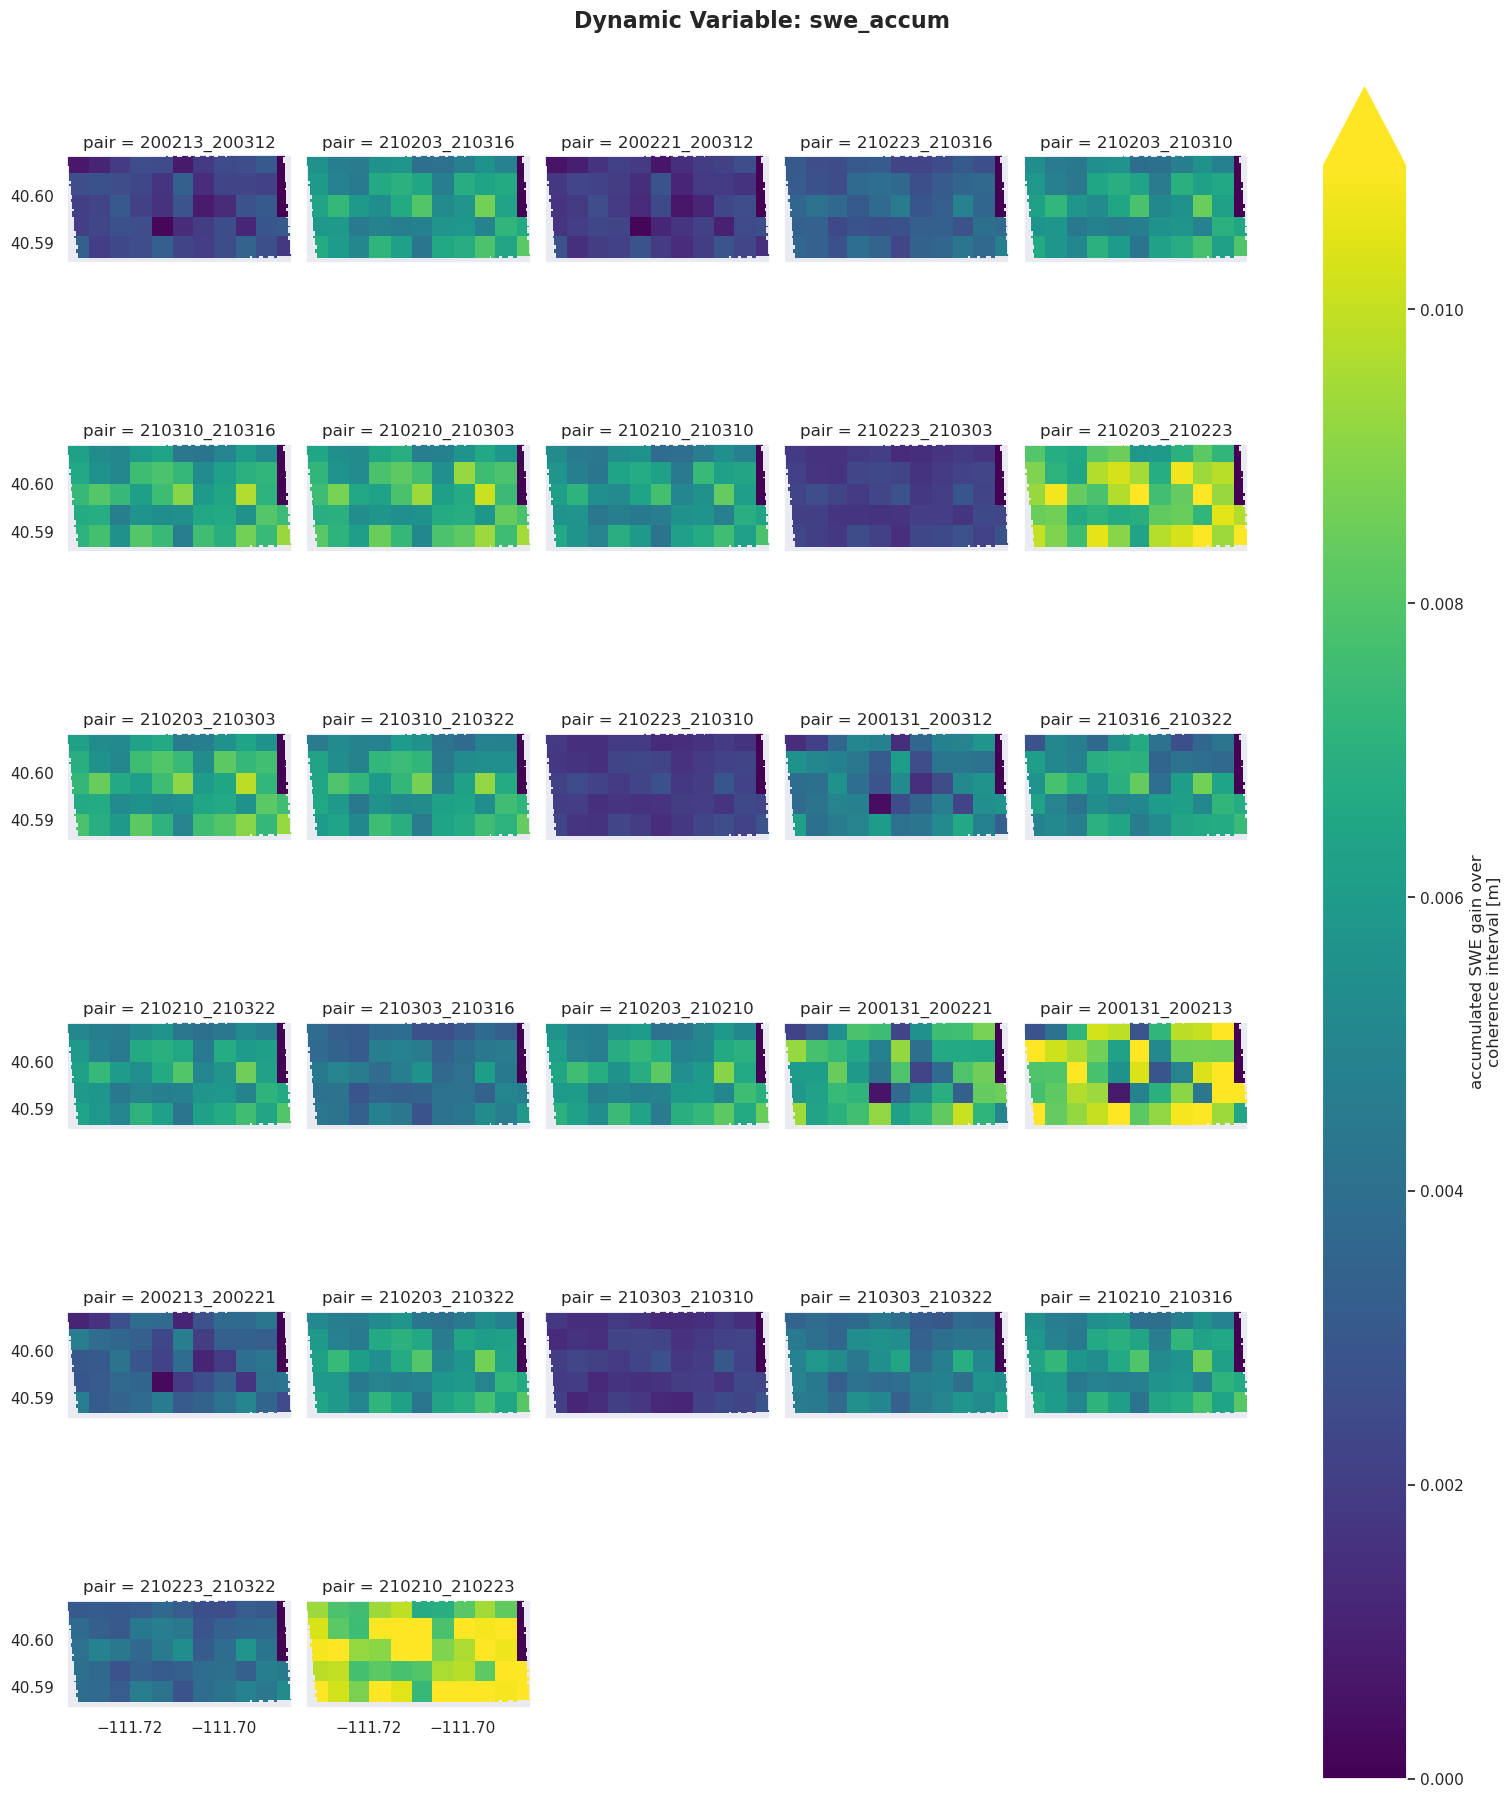

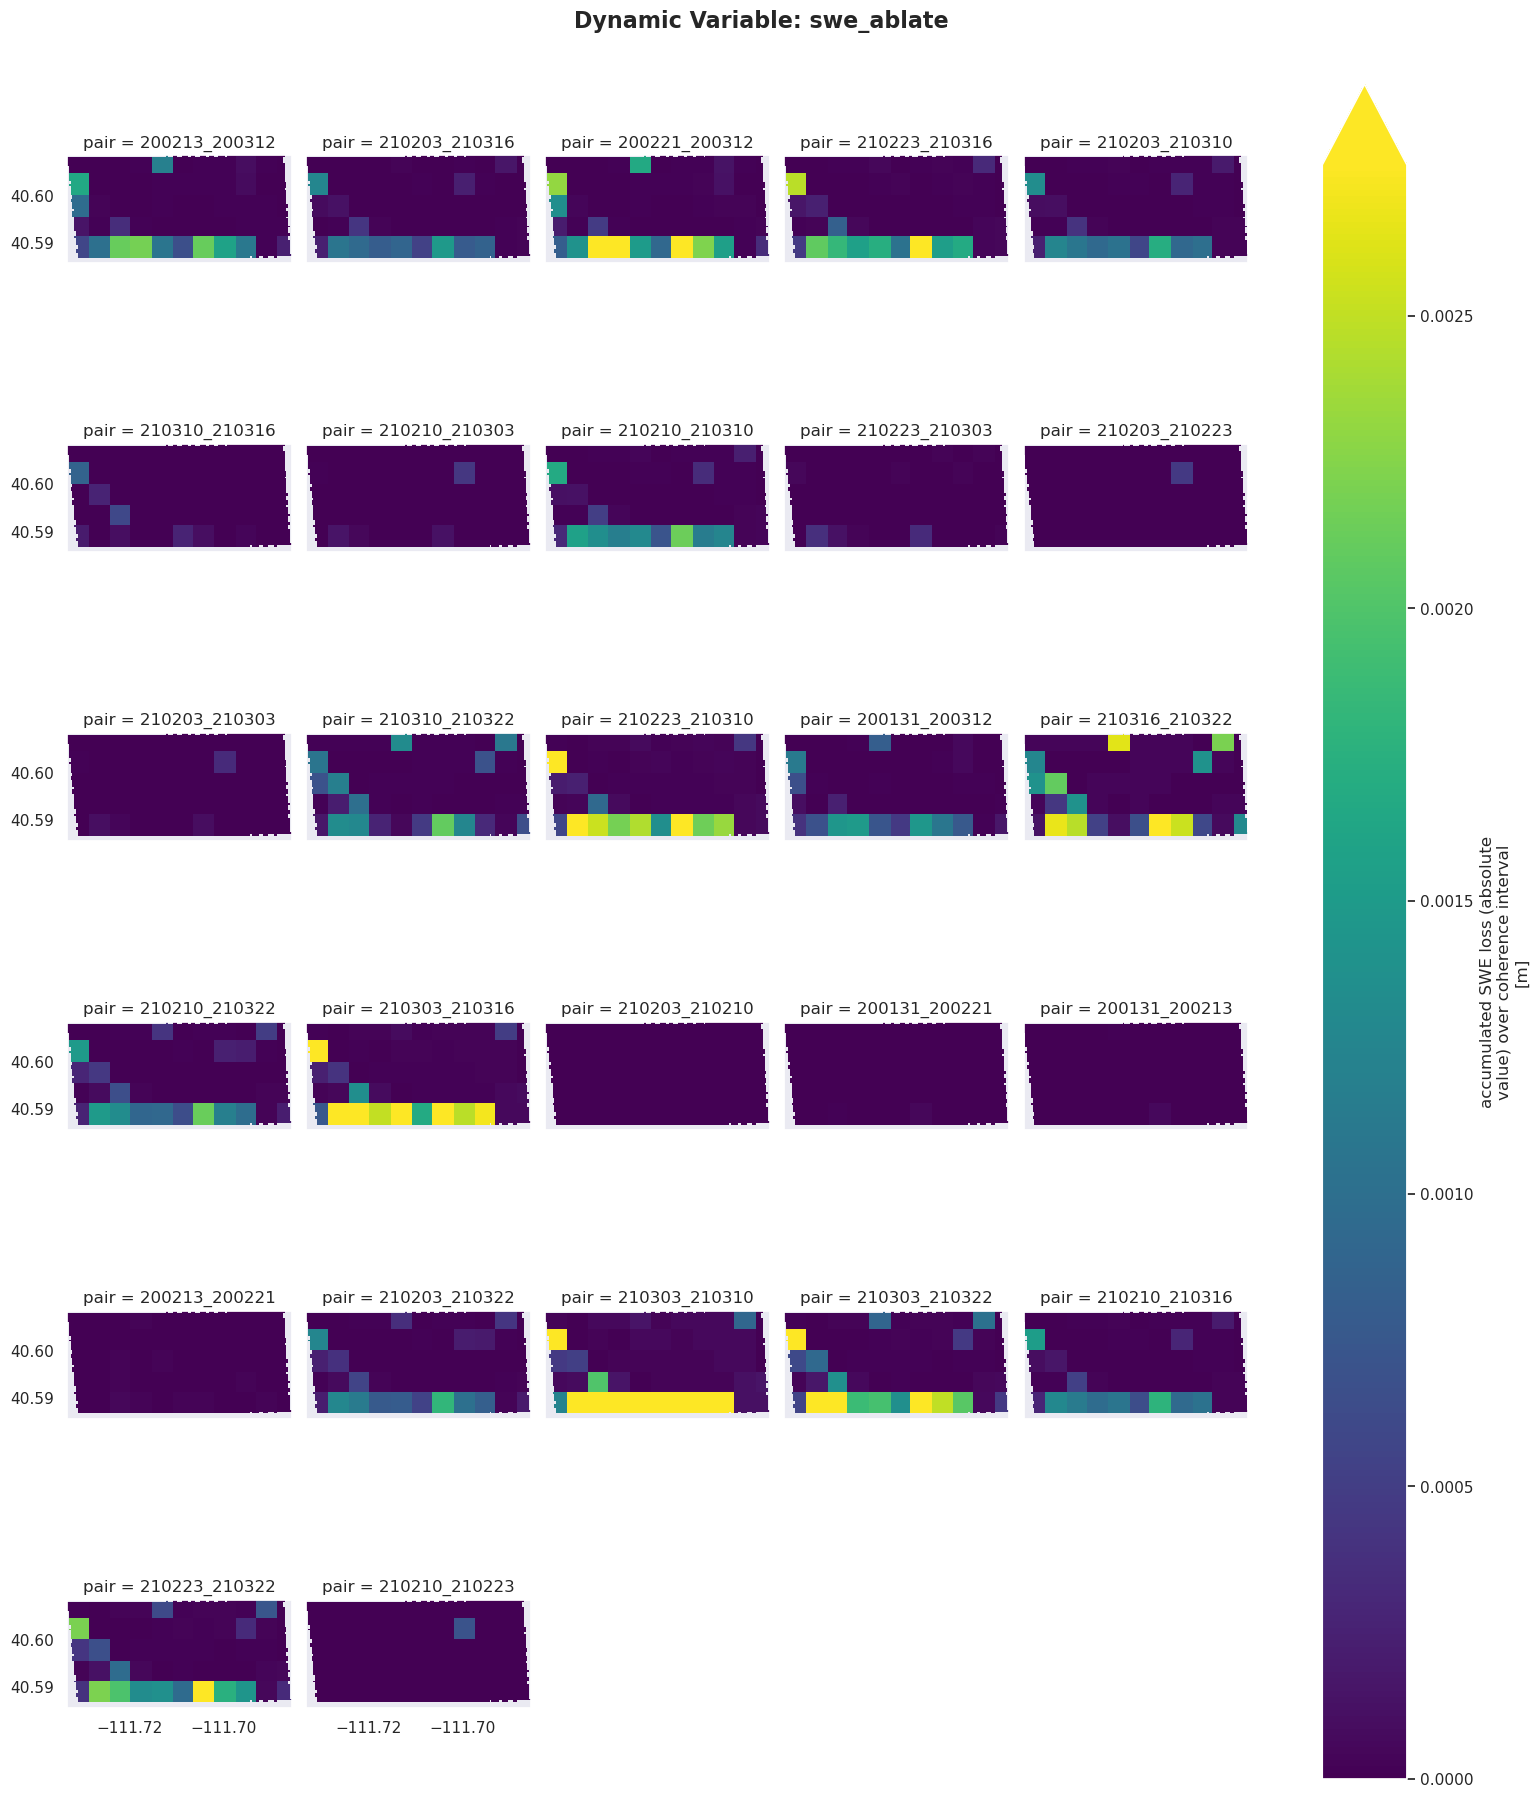

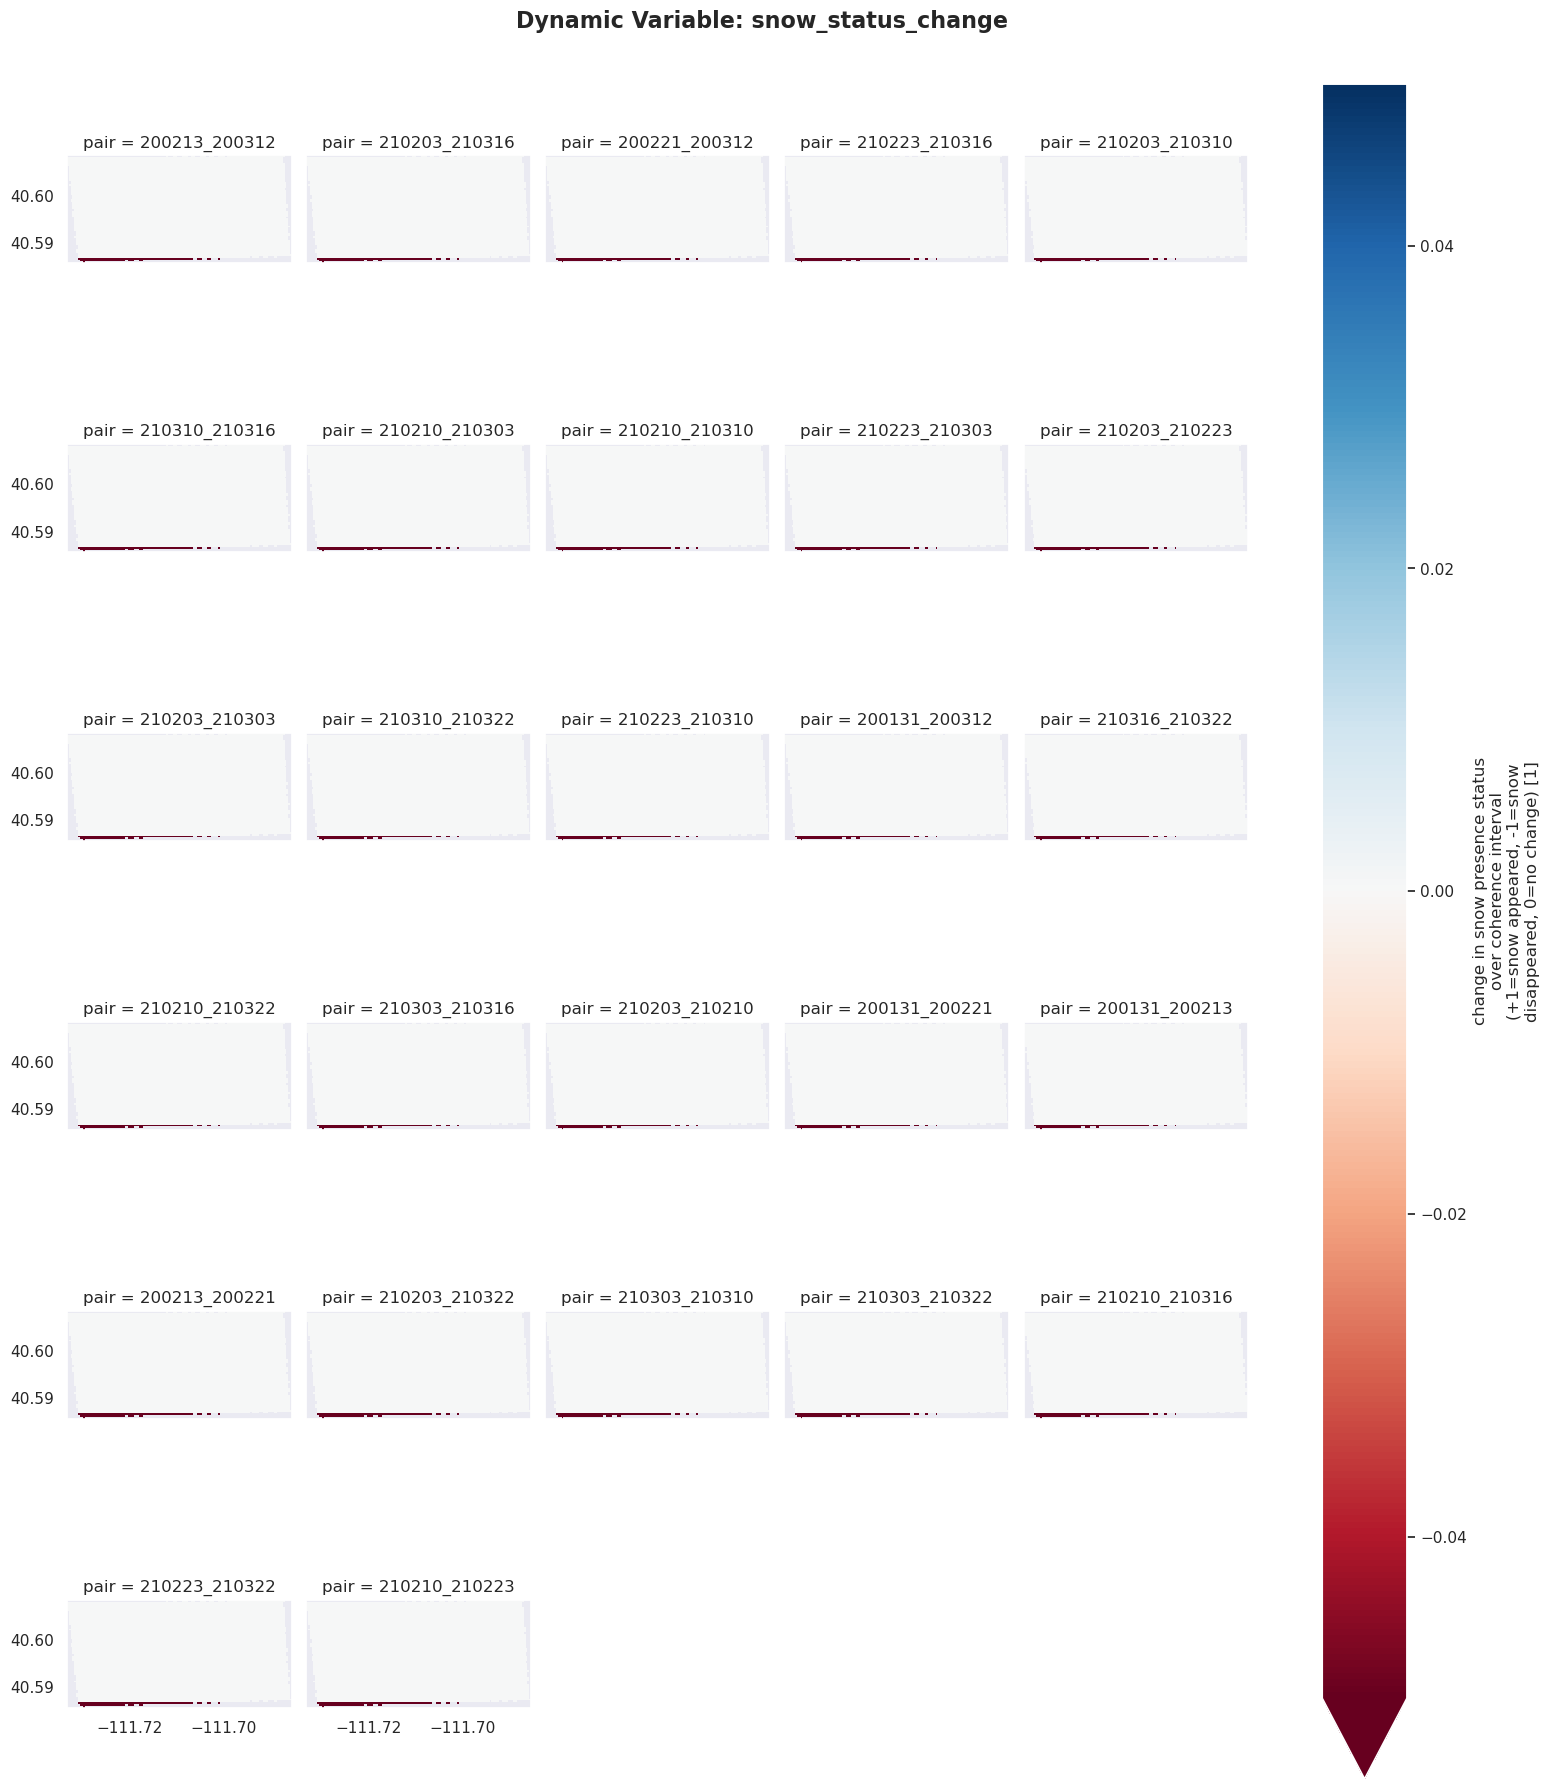

In [16]:
data 
# 1. Separate variables into two lists based on their dimensions
static_vars = [var for var in data.data_vars if 'pair' not in data[var].dims]
pair_vars = [var for var in data.data_vars if 'pair' in data[var].dims]

# ==========================================
# 2. PLOT STATIC VARIABLES (Single Dashboard)
# ==========================================
n_static = len(static_vars)
cols = 3
rows = int(np.ceil(n_static / cols))

# Create one figure for all static variables
fig_static, axes_static = plt.subplots(rows, cols, figsize=(cols * 4, rows * 3.5))
axes_static = axes_static.flatten()

for i, var in enumerate(static_vars):
    ax = axes_static[i]
    
    if var in 'aspect' : cmap = 'twilight'  # cyclic colormap for aspect
    elif var in ['snow_class', 'cover_2019']: cmap = 'tab10'  # categorical colormap for classes
    elif var in 'incidence_angle': cmap = 'viridis_r'
    else: cmap = 'viridis'  # standard colormap for other variables

    # robust=True drops top/bottom 2% of extreme values for a prettier color stretch
    data[var].plot(ax=ax, robust=True, cmap=cmap) 

    
    ax.set_title(var, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_aspect('equal') # Keeps pixels square since this is spatial data

# Hide any empty subplots if n_static doesn't divide perfectly by 3
for j in range(i + 1, len(axes_static)):
    axes_static[j].set_visible(False)

fig_static.suptitle('Static Site Variables (2019/Topography)', fontsize=16, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()


# ==========================================
# 3. PLOT DYNAMIC VARIABLES (One Figure Each)
# ==========================================
for var in pair_vars:
    # Pick a diverging colormap for 'change' variables, standard for others
    cmap = 'RdBu' if 'change' in var else 'viridis'
    
    # Xarray automatically creates a multi-panel figure when you use col=
    # plot only nearest_dates
    fg = data[var].plot(
        col='pair',
        col_wrap=5,  # 5 plots per row looks nice for 45 pairs
        # figsize=(15, 3 * int(np.ceil(len(data[var].sizes) / 5))),
        robust=True,
        cmap=cmap
    )

    # fg = data[var].plot(
    #     col='pair',
    #     col_wrap=5,  # 5 plots per row looks nice for 45 pairs
    #     figsize=(15, 3 * int(np.ceil(data.sizes['pair'] / 5))),
    #     robust=True,
    #     cmap=cmap
    # )
    
    # Add a main title for this specific variable's figure
    fg.fig.suptitle(f'Dynamic Variable: {var}', fontsize=16, fontweight='bold', y=1.02)
    
    # Clean up the individual axes
    for ax in fg.axs.flat:
        ax.set_xlabel('')
        ax.set_ylabel('')
        ax.set_aspect('equal')
        
    plt.show()

## Filter the data down

In [69]:
# find good pixels 

condition = (data['incidence_angle'] < 80) & \
            (data['canopy_2019'] < 30) 
            # (data['elevation'] > 3400)
            # (data['cover_2019'] > 50) & (data['cover_2019'] < 80) & \
data_good = data.where(condition)

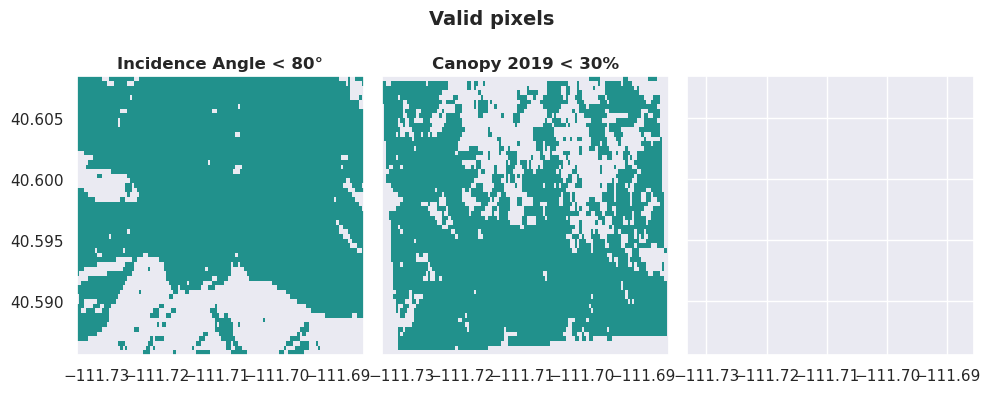

In [74]:
conditions = {
    "Incidence Angle < 80°": data['incidence_angle'] < 80,
    "Canopy 2019 < 30%": data['canopy_2019'] < 30,
    # "Cover 2019 (Shrubs)": (data['cover_2019'] > 50) & (data['cover_2019'] < 80),
    # "Elevation > 3400m": data['elevation'] > 3400
}

# 2. Set up a 2x2 grid of subplots
fig, axes = plt.subplots(1, 3, figsize=(10, 4), sharex=True, sharey=True)
axes = axes.ravel()  # Flatten the 2x2 grid into a 1D array for easy looping

# 3. Loop through and plot each isolated condition
for i, (title, cond) in enumerate(conditions.items()):
    ax = axes[i]
    
    # Use .where() to keep data where True, and set where False to NaN.
    # We can just plot 'cond' itself, or apply it to a variable like 'coherence'
    # if you want to see the underlying data values that passed.
    masked_slice = cond.where(cond) 
    
    # Squeeze out any extra dimensions (like band/time) if they exist
    masked_slice = masked_slice.squeeze()
    
    # Plot using xarray's native plotting wrapper, matching your style
    masked_slice.plot(
        ax=ax,
        cmap='viridis',     # Viridis will color the 'True' pixels
        add_colorbar=False
    )
    
    # Clean up the subplot
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('')  # Remove repetitive x/y labels if sharing axes
    ax.set_ylabel('')

# Add a main title and clean up layout
plt.suptitle("Valid pixels", 
             fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

In [62]:
def plot_cube_vs_target(ds: xr.Dataset, target_var: str = 'coherence', ncols: int = 5, gridsize: int = 50):
    """
    Plots variables in an xarray Dataset against a target variable using hexbin density plots.
    
    Parameters:
    - ds: xarray.Dataset containing the data cube.
    - target_var: The variable to plot on the y-axis (default: 'coherence').
    - ncols: Number of columns for the subplot grid (default: 5).
    - gridsize: The number of hexagons in the x-direction (default: 50).
    """
    # 1. Identify variables to plot (exclude the target variable itself)
    if target_var not in ds.data_vars:
        raise ValueError(f"Target variable '{target_var}' not found in the dataset.")
        
    vars_to_plot = [var for var in ds.data_vars if var != target_var]
    n_vars = len(vars_to_plot)
    
    # Calculate required rows based on number of variables and requested columns
    nrows = math.ceil(n_vars / ncols)
    
    # 2. Flatten Data: Convert to DataFrame and drop NaNs
    # We only convert the variables we actually need to save memory
    cols_to_keep = vars_to_plot + [target_var]
    df = ds[cols_to_keep].to_dataframe().dropna()
    
    # 3. Setup the figure
    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
    
    # Flatten axes array for easy 1D iteration (handles cases where nrows=1 or ncols=1)
    if n_vars == 1:
        axes = np.array([axes])
    else:
        axes = axes.flatten()
        
    # 4. Generate the Hexbin Plots
    for i, var in enumerate(vars_to_plot):
        ax = axes[i]
        
        # Create the hexbin plot
        hb = ax.hexbin(
            x=df[var], 
            y=df[target_var], 
            gridsize=gridsize, 
            cmap='viridis', 
            mincnt=1,      # Only color hexagons that contain at least 1 point
            # bins='log'     # Use logarithmic color scaling for highly dense data
        )
        
        ax.set_xlabel(var)
        ax.set_ylabel(target_var)
        ax.set_title(f'{var} vs {target_var}')
        
        # Add a localized colorbar for each subplot
        cb = fig.colorbar(hb, ax=ax, fraction=0.046, pad=0.04)
        # cb.set_label('log10(N)')
        
    # Hide any leftover empty subplots in the grid
    for j in range(n_vars, len(axes)):
        axes[j].set_visible(False)
        
    plt.tight_layout()
    plt.show()
    
    # 5. Memory Cleanup
    # Explicitly delete the large DataFrame and force python to run garbage collection
    del df

In [70]:
pair_variables = [var for var in data_good.data_vars if 'pair' in data_good[var].dims]
ds_temporal = data_good[pair_variables]

# 2. Sort the pairs chronologically so the time series flows correctly
ds_temporal = ds_temporal.sortby('pair')

# 3. Calculate the median across spatial dimensions (x, y) 
# and squeeze out the single flight_id dimension
ds_reduced = ds_temporal.median(dim=['x', 'y']).squeeze()

# 4. Drop non-essential coordinates and convert to a clean Pandas DataFrame
coords_to_drop = [c for c in ds_reduced.coords if c != 'pair']
df_medians = ds_reduced.drop_vars(coords_to_drop).to_dataframe()

# Inspect the dataframe to make sure it looks like a clean table
df_medians

,coherence,mean_temp,max_temp,total_precip,avg_precip,total_rain,avg_rain,total_snow,avg_snow,acq_day_precip,mean_wind,max_wind
pair,,,,,,,,,,,,
200131_200213,0.280220,-6.820284,9.050004,149.800002,0.478594,0.0,0.000000,149.800002,0.478594,0.2,5.234484,17.393390
200131_200221,0.282467,-6.891580,9.050004,192.200003,0.380594,0.0,0.000000,192.200003,0.380594,0.2,4.926493,17.393390
200131_200312,0.268184,-4.217204,10.350004,225.800003,0.229239,4.6,0.004670,221.200003,0.224569,0.2,4.563943,17.393390
200213_200221,0.376984,-7.005955,2.450004,42.400001,0.219689,0.0,0.000000,42.400001,0.219689,0.0,4.415296,11.700000
200213_200312,0.312081,-3.010174,10.350004,76.000001,0.112927,4.6,0.006835,72.500001,0.107727,0.0,4.249236,13.136590
200221_200312,0.513837,-1.401555,10.350004,33.400000,0.069439,4.6,0.009563,29.400000,0.061123,0.0,4.179295,13.136590
210203_210210,0.460067,-3.960055,5.050004,38.500001,0.227811,1.4,0.008284,37.100001,0.219527,0.0,5.425033,10.878419
210203_210223,0.267724,-5.588250,5.050004,150.200002,0.312266,1.4,0.002911,150.200002,0.312266,0.0,4.239865,10.878419
210203_210303,0.258389,-6.238852,5.050004,155.300002,0.230758,1.4,0.002080,155.300002,0.230758,0.0,4.060708,10.878419


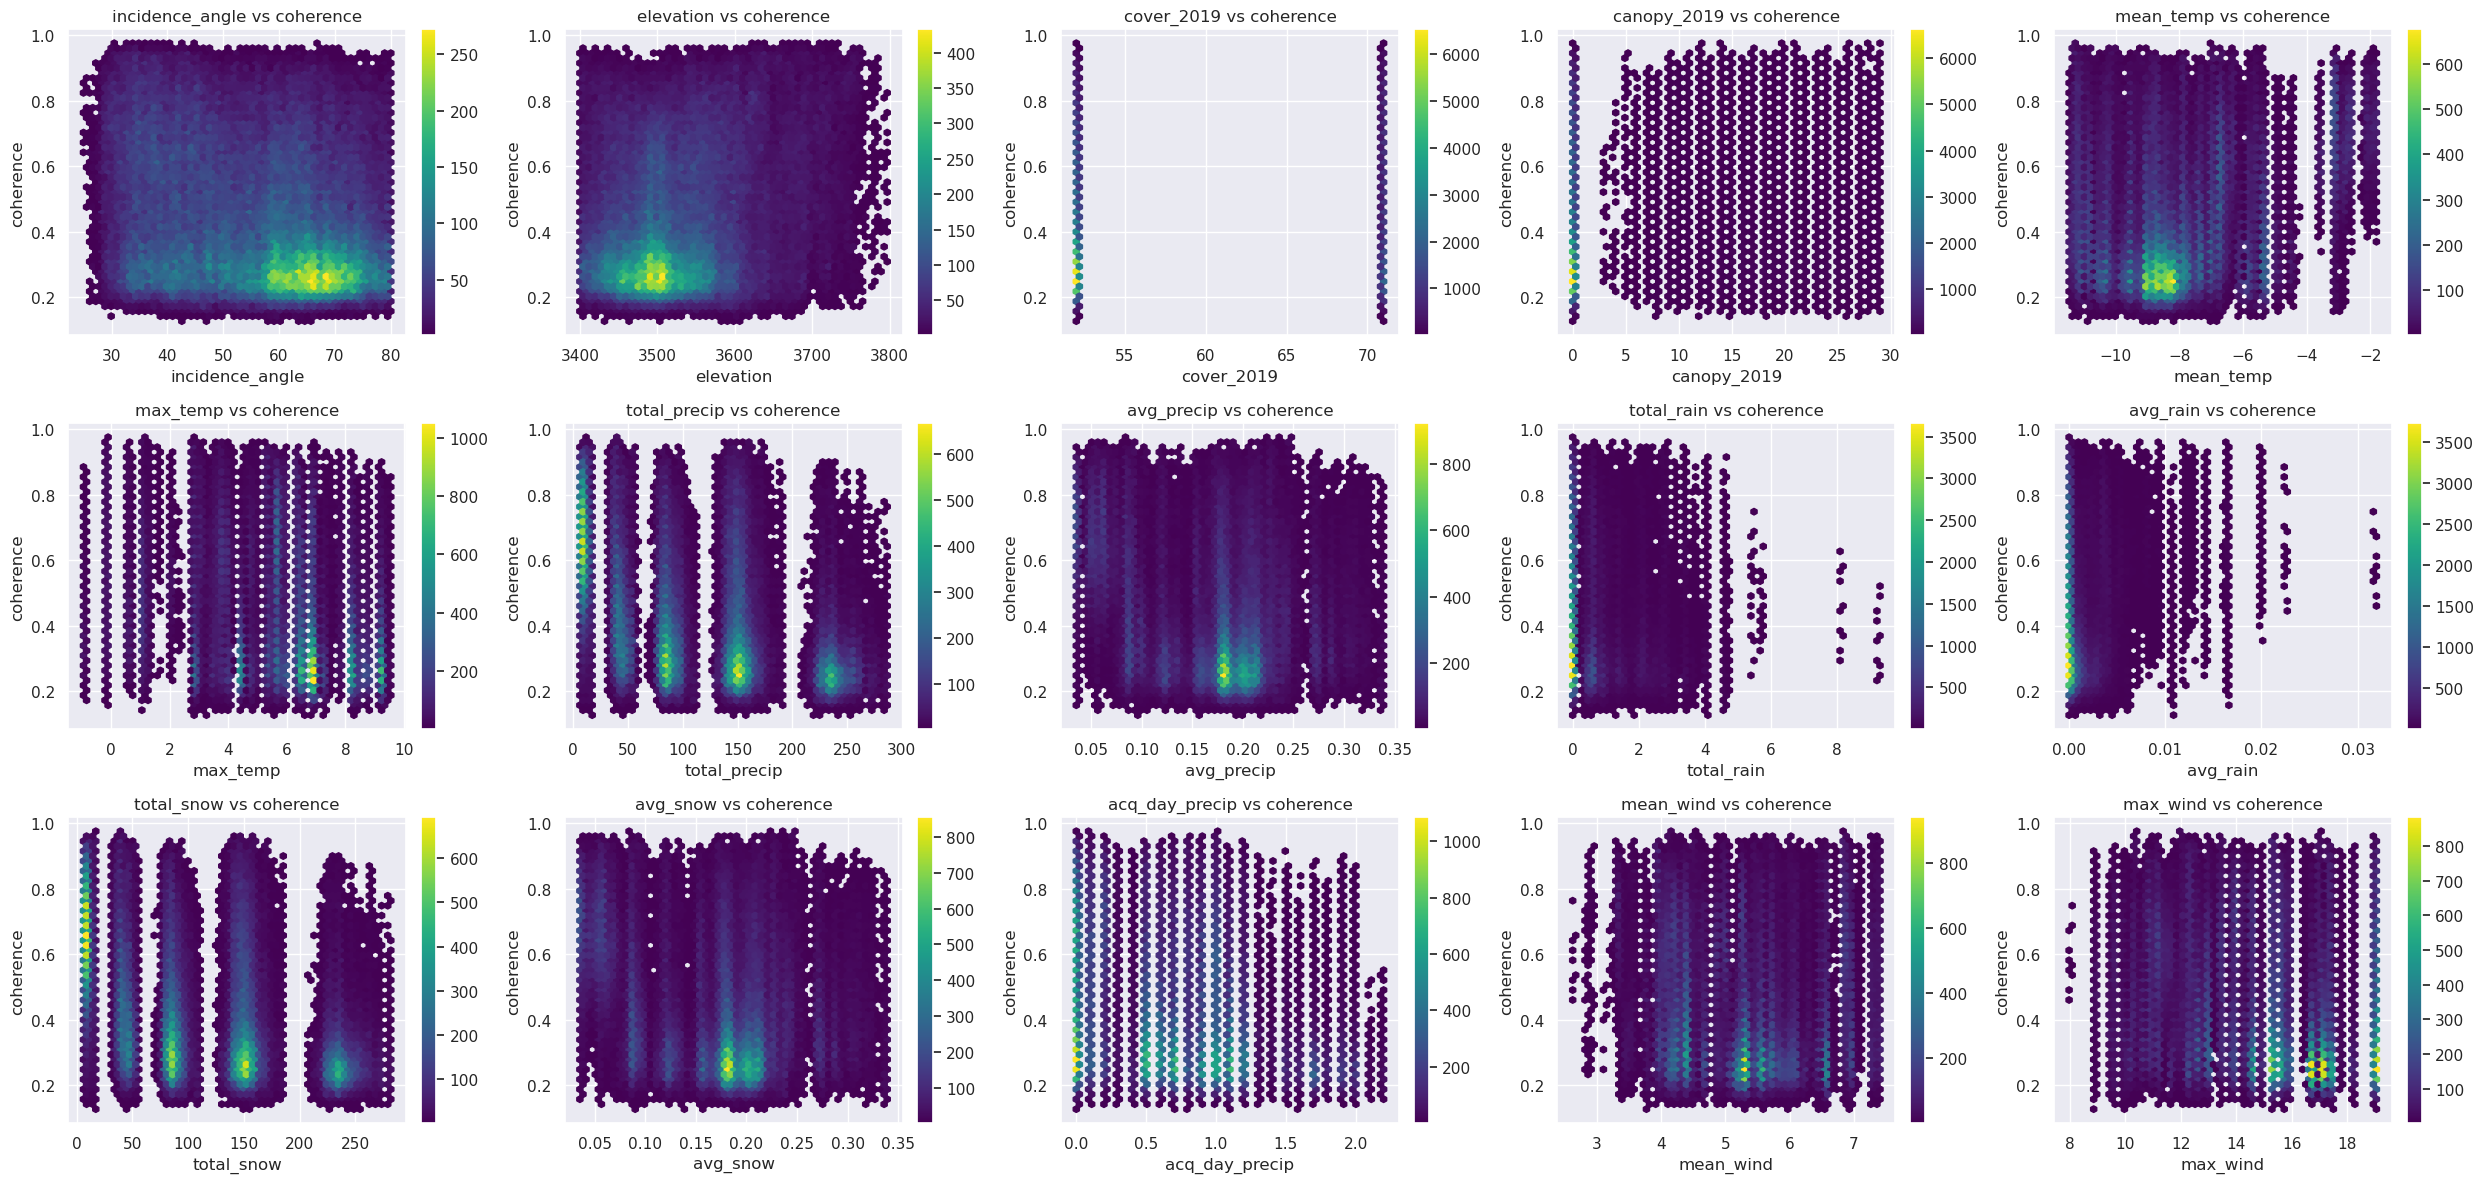

In [77]:
plot_cube_vs_target(data_good)

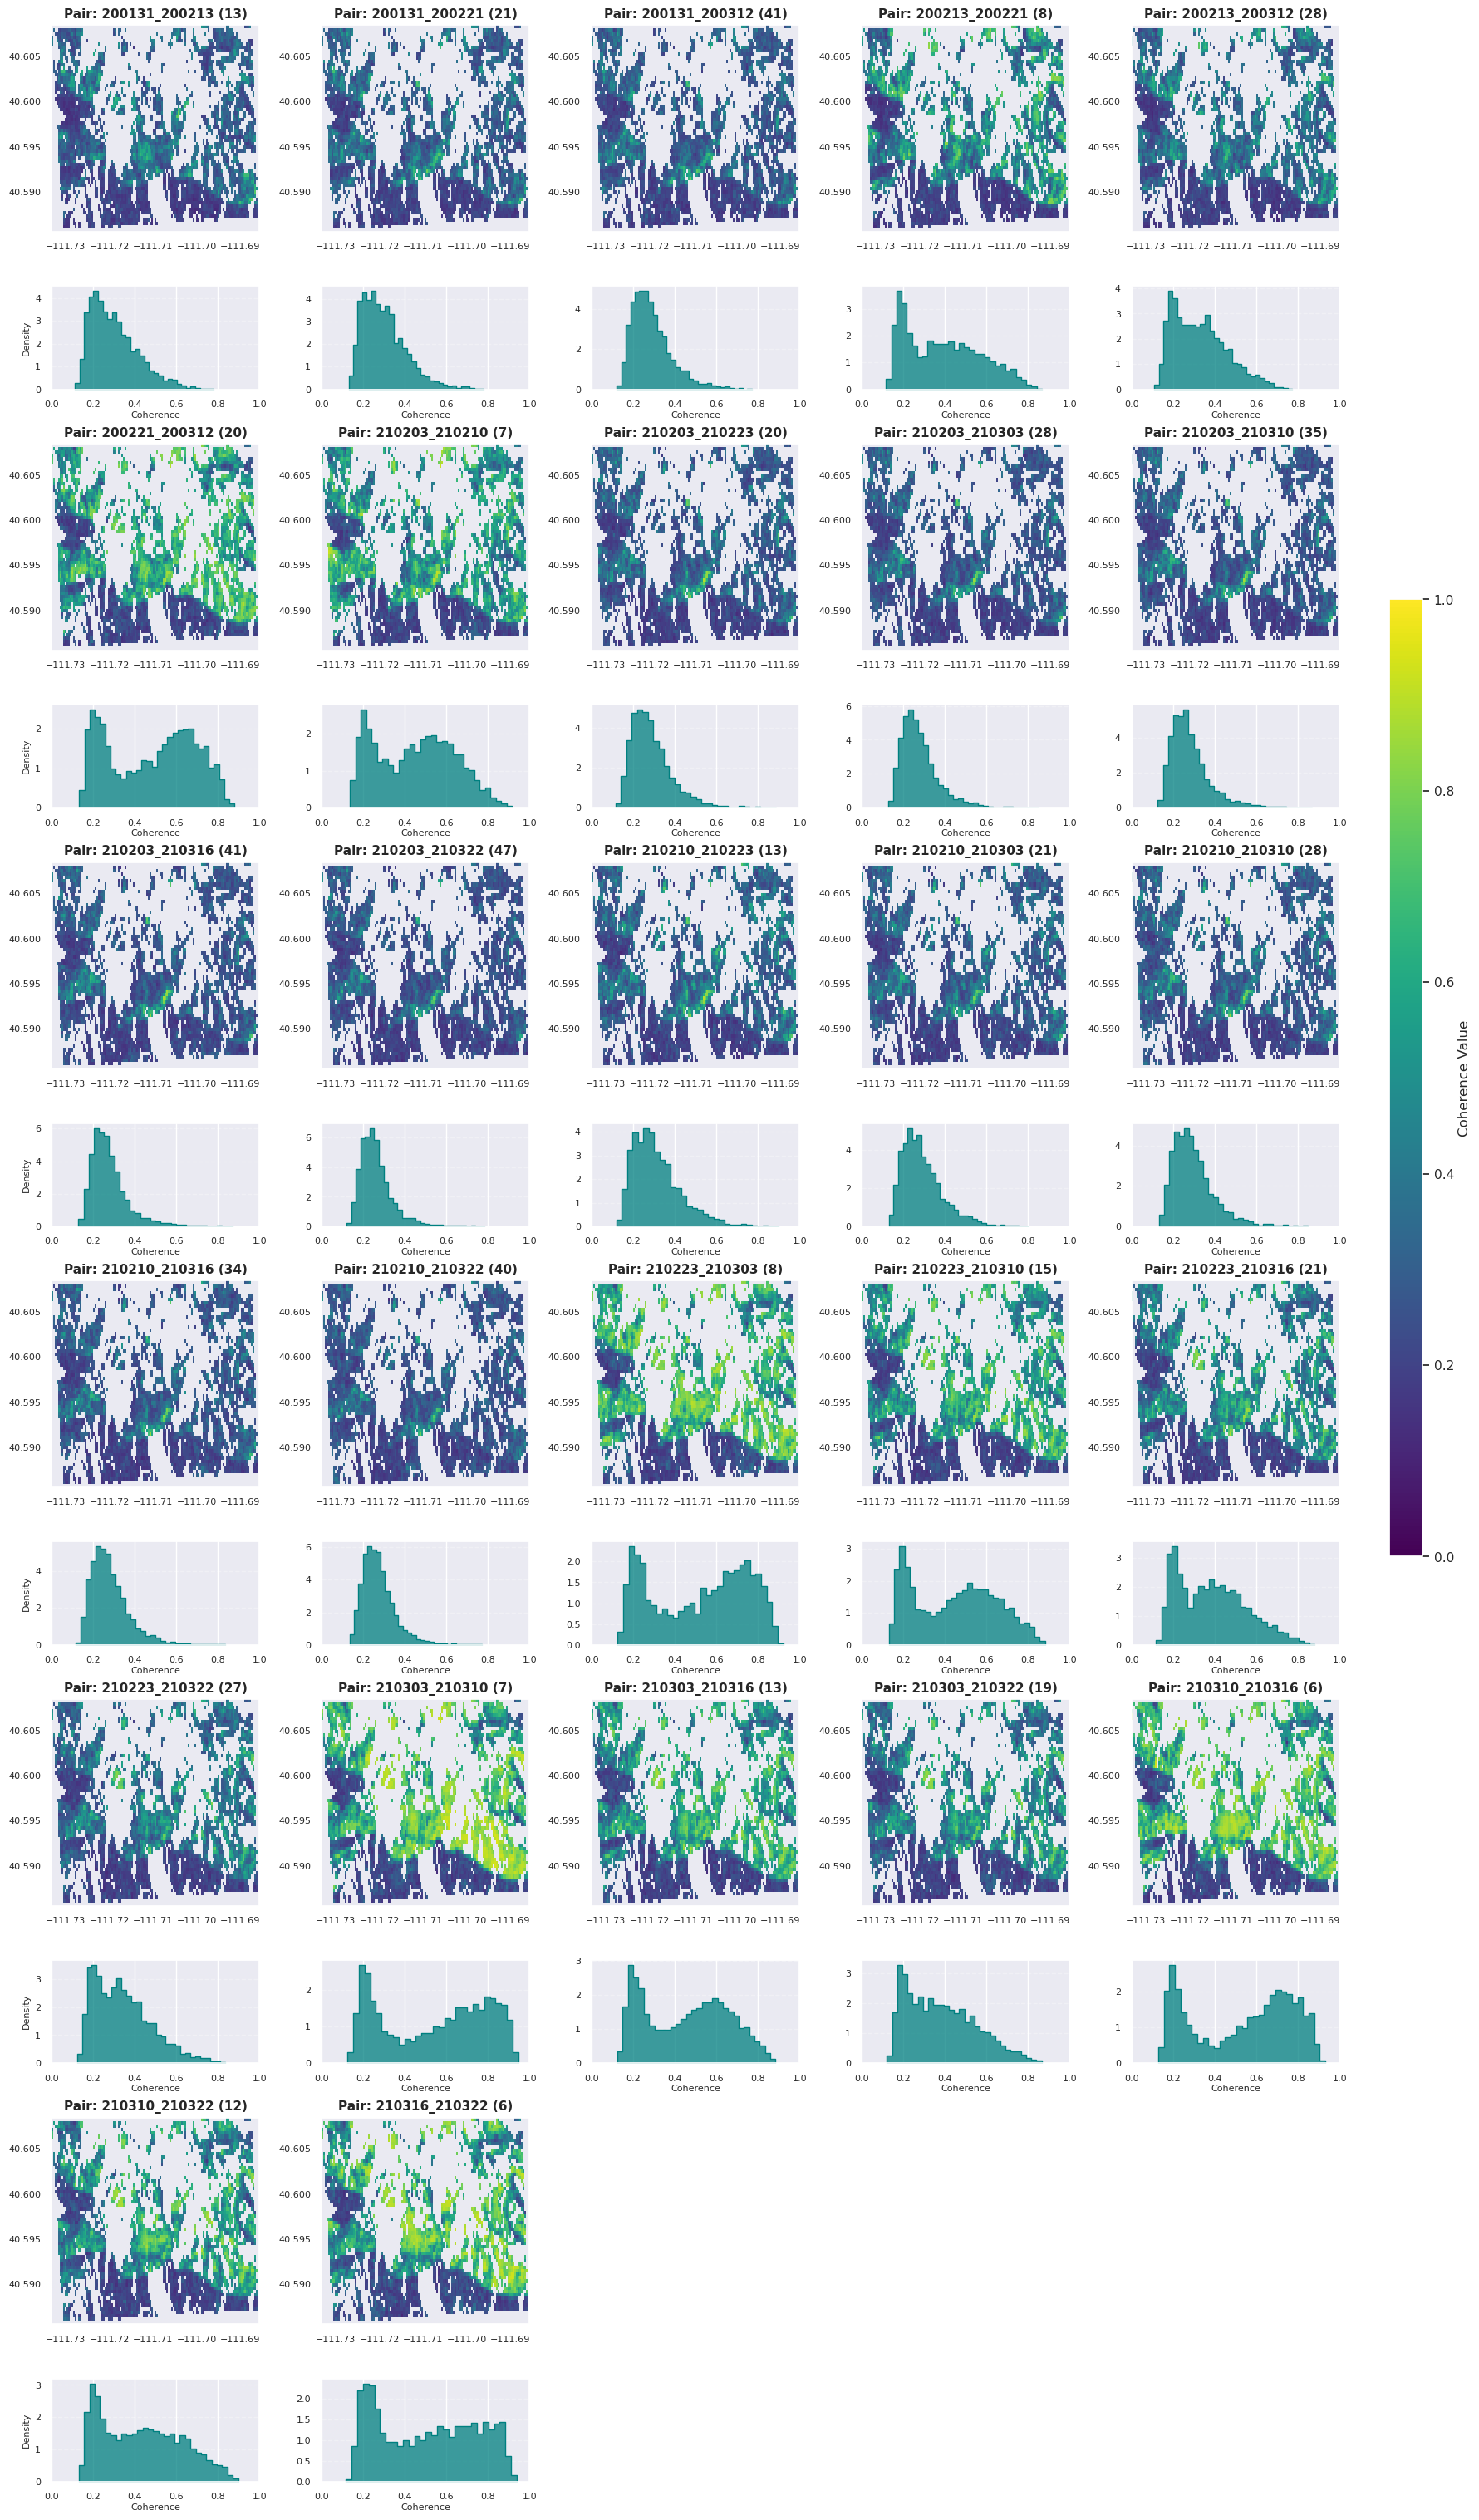

In [75]:
ds_sorted = data_good.sortby('pair')
pairs = ds_sorted.pair.values
num_pairs = len(pairs)

# 2. Configure the 5-column grid layout
ncols = 5
num_groups = (num_pairs + ncols - 1) // ncols
nrows = num_groups * 2 

# --- THE FIX: Create alternating height ratios (Map = 2, Hist = 1) ---
# For 3 groups (6 rows), this generates: [2, 1, 2, 1, 2, 1]
row_height_ratios = []
for _ in range(num_groups):
    row_height_ratios.extend([2, 1])

# Create the master canvas using the new height ratios
fig, axes = plt.subplots(
    nrows=nrows, 
    ncols=ncols, 
    figsize=(4 * ncols, 3.2 * nrows), # Slightly reduced multiplier to account for shorter hists
    gridspec_kw={
        'hspace': 0.35, 
        'wspace': 0.3,
        'height_ratios': row_height_ratios  # <-- Directly scales row heights
    }
)

# 3. Loop through every pair and assign them to the correct grid slots
for idx, pair_name in enumerate(pairs):
    col = idx % ncols
    group = idx // ncols
    row_map = group * 2
    row_hist = (group * 2) + 1
    
    ax_map = axes[row_map, col]
    ax_hist = axes[row_hist, col]
    
    # Extract the 2D spatial slice for this specific pair
    coh_slice = ds_sorted['coherence'].sel(pair=pair_name).squeeze()
    
    # --- TOP PLOT: Spatial Map ---
    coh_slice.plot(
        ax=ax_map, 
        cmap='viridis', 
        vmin=0, 
        vmax=1, 
        add_colorbar=False
    )
    t1, t2 = [datetime.strptime(d, "%y%m%d") for d in pair_name.split("_")]
    # Calculate the difference in days
    days_elapsed = (t2 - t1).days
    ax_map.set_title(f"Pair: {pair_name} ({days_elapsed})", fontsize=11, fontweight='bold')
    ax_map.set_xlabel("")
    ax_map.set_ylabel("")
    ax_map.tick_params(labelsize=8)
    
    # --- BOTTOM PLOT: Histogram (Half Height) ---
    flattened_vals = coh_slice.values.flatten()
    clean_vals = flattened_vals[~np.isnan(flattened_vals)]
    
    sns.histplot(
        clean_vals, 
        bins=30, 
        kde=False, 
        ax=ax_hist, 
        color='teal', 
        element='step',
        stat='density'
    )
    ax_hist.set_xlim(0, 1)
    ax_hist.set_xlabel("Coherence", fontsize=8, labelpad=2)
    ax_hist.set_ylabel("Density" if col == 0 else "", fontsize=8)
    ax_hist.tick_params(labelsize=8)
    ax_hist.grid(axis='y', linestyle='--', alpha=0.3)

# 4. Clean up and delete any empty subplot slots in the final row group
for blank_idx in range(idx + 1, num_groups * ncols):
    b_col = blank_idx % ncols
    b_group = blank_idx // ncols
    
    fig.delaxes(axes[b_group * 2, b_col])     
    fig.delaxes(axes[(b_group * 2) + 1, b_col]) 

# 5. Add a single, unified colorbar on the right side of the entire figure
mappable = plt.cm.ScalarMappable(cmap='viridis', norm=plt.Normalize(vmin=0, vmax=1))
cbar_ax = fig.add_axes([0.93, 0.4, 0.02, 0.3]) 
fig.colorbar(mappable, cax=cbar_ax, label='Coherence Value')

plt.suptitle("", fontsize=16, fontweight='bold', y=0.99)
plt.show()


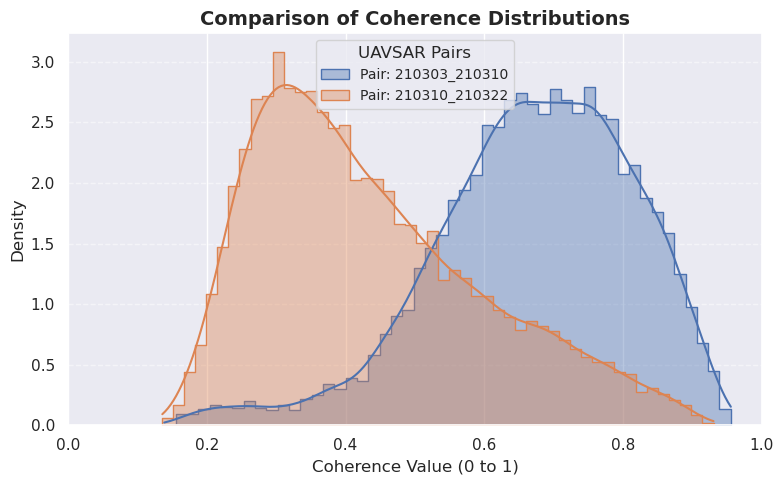

In [72]:
chosen_pairs = ['210303_210310', '210310_210322'] 

plt.figure(figsize=(8, 5))

# 2. Loop through each chosen pair and plot its distribution
for pair_name in chosen_pairs:
    # .sel() extracts the specific pair
    # .squeeze() removes the single-value 'flight_id' dimension
    # .values gets the raw numpy array
    pixel_data = data_good['coherence'].sel(pair=pair_name).squeeze().values
    
    # Flatten the 2D (y, x) array into a 1D vector of numbers
    flattened_vals = pixel_data.flatten()
    
    # CRITICAL: Drop NaN values (pixels outside the flight track/AOI)
    clean_vals = flattened_vals[~np.isnan(flattened_vals)]
    
    # 3. Plot the distribution
    sns.histplot(
        clean_vals,
        kde=True,            # Adds a smooth kernel density estimate curve
        label=f"Pair: {pair_name}",
        alpha=0.4,           # Transparency (0 = invisible, 1 = solid)
        bins=50,             # Number of bins between 0 and 1
        element="step",      # 'step' style looks cleaner when overlapping
        stat="density"       # Normalizes count if pairs have different pixel counts
    )

# 4. Format and style the plot
plt.title("Comparison of Coherence Distributions", fontsize=14, fontweight='bold')
plt.xlabel("Coherence Value (0 to 1)", fontsize=12)
plt.ylabel("Density", fontsize=12)

# Coherence is theoretically strictly bounded between 0 and 1
plt.xlim(0, 1) 

plt.legend(title="UAVSAR Pairs", fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()